# Compare All Estimators: MLE vs TURBOLFI vs Adaptive Sampler vs BI

This notebook compares parameter recovery across **four estimators** for a discrete choice (MNL) model (P=10 parameters):

| Estimator | Description | Data source |
|---|---|---|
| **MLE** | Maximum Likelihood Estimation with Sampling of Alternatives | `results/mle_sa_comparison_ready.csv` |
| **TURBOLFI** | Likelihood-free inference via TuRBO+BOLFI | `TUBOLFI/results/J*/MCMC_summary.csv` |
| **Adaptive Sampler** | Gibbs sampler with adaptive choice set | `results/comparisons/all_arviz_summaries.csv` |
| **BI** | Full Bayesian inference (benchmark) | `results/comparisons/biogeme_BI_m0_parameter_metrics.csv` |

**Configs explored**: J ∈ {100, 200, 500}, N ∈ {10k, 20k, 50k}, P=10 (fixed)

**Analysis includes:**
- Parameter recovery: posterior mean vs true value, 95% HDI coverage
- Per-parameter forest plots across estimators and configs
- Effect of J (choice set size) and N (population size)
- Overall statistics: coverage rate, RMSE, MAE, interval width
- Convergence diagnostics: R-hat, ESS

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_rows', 200)

# Paths
# Paths inside this repository
REPO_ROOT = REPO_ROOT = Path.cwd().parent

MLE_SA_CSV = (
    REPO_ROOT
    / "results"
    / "mle_sa_comparison_ready_no_starting_betas.csv"
)

TURBOLFI_RESULTS_DIR = (
    REPO_ROOT
    / "results"
    / "tubolfi_results"
    / "all"
)

ADAPTIVE_CSV = (
    REPO_ROOT
    / "results"
    / "all_arviz_summaries_timed_2.csv"
)

BI_CSV = (
    REPO_ROOT
    / "results"
    / "biogeme_BI_m0_parameter_metrics_96.csv"
)


# Parameter names for P=10
PARAM_NAMES_P10 = [
    'beta_rating', 'beta_cost', 'beta_log_dist',
    'beta_chinese', 'beta_japanese', 'beta_korean',
    'beta_indian', 'beta_french', 'beta_mexican', 'beta_lebanese',
]

# True parameter values (M=0)
TRUE_VALUES_P10 = {
    'beta_rating':   0.75,
    'beta_cost':    -0.40,
    'beta_log_dist':-0.60,
    'beta_chinese':  0.83,
    'beta_japanese': 1.25,
    'beta_korean':   0.75,
    'beta_indian':   1.00,
    'beta_french':   0.95,
    'beta_mexican':  1.30,
    'beta_lebanese': 0.90,
}

# Estimator style
ESTIMATOR_COLORS   = {'MLE': 'C3', 'TURBOLFI': 'C1', 'AdaptiveSampler': 'C0', 'BI': 'C2'}
ESTIMATOR_MARKERS  = {'MLE': 'D',  'TURBOLFI': 's',  'AdaptiveSampler': 'o',  'BI': '^'}
ESTIMATOR_LABELS   = {'MLE': 'MLE (SA)', 'TURBOLFI': 'TURBOLFI', 'AdaptiveSampler': 'Adaptive Sampler', 'BI': 'BI (full set)'}
N_LINESTYLES       = {10000: ':', 20000: '--', 50000: '-'}
N_LABELS           = {10000: '10k', 20000: '20k', 50000: '50k'}

# Choose which TuRBO result to showcase
TURBOLFI_MODE = "iter_max"
# TURBOLFI_MODE = "early_stop"

TURBOLFI_SUMMARY_FILE = f"MCMC_summary_{TURBOLFI_MODE}.csv"

## 1. Load TURBOLFI Results

Scan all `TUBOLFI/results/J*_P10_N*_I0C0M0_D5+6_SIM30/MCMC_summary.csv` folders, parse the config (J, N, P) from the directory name, and build a unified dataframe.

In [20]:
def parse_turbolfi_dirname(dirname):
    """Parse J, N, P from a TuRBO directory name."""
    s = str(dirname)

    j_match = re.search(r"J(\d+)", s)
    p_match = re.search(r"P(\d+)", s)
    n_match = re.search(r"N(\d+)k", s)

    if not (j_match and p_match and n_match):
        return None

    return {
        "J": int(j_match.group(1)),
        "P": int(p_match.group(1)),
        "N": int(n_match.group(1)) * 1000,
    }


TARGET_SUFFIX = "I0C0M0_D5+6_SIM30"

all_turbolfi = []

folders = sorted(
    TURBOLFI_RESULTS_DIR.glob(f"*_{TARGET_SUFFIX}")
)

print(
    f"Found {len(folders)} TuRBO folders. "
    f"Loading mode: {TURBOLFI_MODE}"
)

for folder in folders:
    cfg = parse_turbolfi_dirname(folder.name)

    if cfg is None:
        print(f"[SKIP] Cannot parse folder name: {folder.name}")
        continue

    if cfg["P"] != 10:
        print(f"[SKIP] P={cfg['P']}: {folder.name}")
        continue

    csv_path = folder / TURBOLFI_SUMMARY_FILE

    if not csv_path.exists():
        print(f"[WARN] Missing: {csv_path}")
        continue

    df = pd.read_csv(csv_path, index_col=0)
    df = df.rename_axis("parameter").reset_index()

    # Keep only the ten P=10 parameters
    df = df[
        df["parameter"].isin(PARAM_NAMES_P10)
    ].copy()

    df["J"] = cfg["J"]
    df["N"] = cfg["N"]
    df["P"] = cfg["P"]

    # Keep one common estimator name throughout the notebook
    df["estimator"] = "TURBOLFI"
    df["turbolfi_mode"] = TURBOLFI_MODE
    df["folder"] = folder.name

    all_turbolfi.append(df)

    print(
        f"[OK] J={cfg['J']}, "
        f"N={cfg['N']//1000}k, "
        f"rows={len(df)}"
    )

df_turbolfi_raw = (
    pd.concat(all_turbolfi, ignore_index=True)
    if all_turbolfi
    else pd.DataFrame()
)

print("\nTuRBO dataframe shape:", df_turbolfi_raw.shape)

if not df_turbolfi_raw.empty:
    display(
        df_turbolfi_raw.head(20)
    )

Found 9 TuRBO folders. Loading mode: iter_max
[OK] J=100, N=10k, rows=10
[OK] J=100, N=20k, rows=10
[OK] J=100, N=50k, rows=10
[OK] J=200, N=10k, rows=10
[OK] J=200, N=20k, rows=10
[OK] J=200, N=50k, rows=10
[OK] J=500, N=10k, rows=10
[OK] J=500, N=20k, rows=10
[OK] J=500, N=50k, rows=10

TuRBO dataframe shape: (90, 18)


,parameter,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,true,covered,J,N,P,estimator,turbolfi_mode,folder
0,beta_rating,0.772,0.051,0.676,0.863,0.002,0.001,644.0,926.0,1.01,0.75,True,100,10000,10,TURBOLFI,iter_max,J100_P10_N10k_I0C0M0_D5+6_SIM30
1,beta_cost,-0.413,0.008,-0.429,-0.400,0.000,0.000,605.0,950.0,1.01,-0.40,True,100,10000,10,TURBOLFI,iter_max,J100_P10_N10k_I0C0M0_D5+6_SIM30
2,beta_log_dist,-0.581,0.043,-0.660,-0.507,0.002,0.001,601.0,1200.0,1.00,-0.60,True,100,10000,10,TURBOLFI,iter_max,J100_P10_N10k_I0C0M0_D5+6_SIM30
3,beta_chinese,0.822,0.129,0.581,1.048,0.006,0.003,528.0,1020.0,1.01,0.83,True,100,10000,10,TURBOLFI,iter_max,J100_P10_N10k_I0C0M0_D5+6_SIM30
4,beta_japanese,1.235,0.063,1.117,1.345,0.003,0.001,570.0,1088.0,1.01,1.25,True,100,10000,10,TURBOLFI,iter_max,J100_P10_N10k_I0C0M0_D5+6_SIM30
5,beta_korean,0.798,0.110,0.587,0.991,0.005,0.002,521.0,953.0,1.01,0.75,True,100,10000,10,TURBOLFI,iter_max,J100_P10_N10k_I0C0M0_D5+6_SIM30
6,beta_indian,0.964,0.155,0.689,1.259,0.006,0.003,685.0,1076.0,1.01,1.00,True,100,10000,10,TURBOLFI,iter_max,J100_P10_N10k_I0C0M0_D5+6_SIM30
7,beta_french,0.837,0.093,0.667,1.010,0.004,0.002,608.0,1070.0,1.01,0.95,True,100,10000,10,TURBOLFI,iter_max,J100_P10_N10k_I0C0M0_D5+6_SIM30
8,beta_mexican,1.283,0.084,1.123,1.433,0.004,0.002,541.0,1143.0,1.01,1.30,True,100,10000,10,TURBOLFI,iter_max,J100_P10_N10k_I0C0M0_D5+6_SIM30
9,beta_lebanese,0.858,0.101,0.670,1.042,0.004,0.002,805.0,1366.0,1.00,0.90,True,100,10000,10,TURBOLFI,iter_max,J100_P10_N10k_I0C0M0_D5+6_SIM30


## 2. Load Adaptive Sampler Results

Read `all_arviz_summaries.csv`, filter to P=10, and rename columns to a shared schema.

In [3]:
df_adaptive_raw = pd.read_csv(ADAPTIVE_CSV)
print(f"Loaded Adaptive Sampler CSV: {df_adaptive_raw.shape}")
print(f"Columns: {list(df_adaptive_raw.columns)}")

# Filter to P=10 only
df_adaptive_raw = df_adaptive_raw[df_adaptive_raw['P'] == 10].copy()
print(f"\nAfter P=10 filter: {df_adaptive_raw.shape}")
print(f"Configs available: {df_adaptive_raw[['J','N']].drop_duplicates().sort_values(['J','N']).to_string(index=False)}")

display(df_adaptive_raw.head(10))

Loaded Adaptive Sampler CSV: (90, 16)
Columns: ['mean', 'sd', 'hdi_3%', 'hdi_97%', 'mcse_mean', 'mcse_sd', 'ess_bulk', 'ess_tail', 'r_hat', 'J', 'N', 'P', 'mtm', 'M', 'file', 'parameter']

After P=10 filter: (90, 16)
Configs available:   J     N
100 10000
100 20000
100 50000
200 10000
200 20000
200 50000
500 10000
500 20000
500 50000


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,J,N,P,mtm,M,file,parameter
0,0.754,0.039,0.679,0.829,0.001,0.001,1298.0,1646.0,1.00,100,10000,10,5,0,trace_J100_N10000_P10_prot2_mtm_steps5000_SCAL...,beta_rating
1,-0.404,0.007,-0.418,-0.391,0.000,0.000,1000.0,1179.0,1.00,100,10000,10,5,0,trace_J100_N10000_P10_prot2_mtm_steps5000_SCAL...,beta_cost
2,-0.582,0.030,-0.641,-0.529,0.001,0.001,1684.0,1167.0,1.00,100,10000,10,5,0,trace_J100_N10000_P10_prot2_mtm_steps5000_SCAL...,beta_log_dist
3,0.892,0.094,0.725,1.064,0.009,0.004,116.0,333.0,1.03,100,10000,10,5,0,trace_J100_N10000_P10_prot2_mtm_steps5000_SCAL...,beta_chinese
4,1.354,0.092,1.196,1.546,0.009,0.004,104.0,270.0,1.04,100,10000,10,5,0,trace_J100_N10000_P10_prot2_mtm_steps5000_SCAL...,beta_japanese
5,0.899,0.110,0.684,1.089,0.009,0.003,146.0,435.0,1.03,100,10000,10,5,0,trace_J100_N10000_P10_prot2_mtm_steps5000_SCAL...,beta_korean
6,1.020,0.137,0.753,1.263,0.008,0.003,268.0,822.0,1.01,100,10000,10,5,0,trace_J100_N10000_P10_prot2_mtm_steps5000_SCAL...,beta_indian
7,0.939,0.099,0.768,1.149,0.009,0.004,133.0,234.0,1.03,100,10000,10,5,0,trace_J100_N10000_P10_prot2_mtm_steps5000_SCAL...,beta_french
8,1.391,0.096,1.195,1.562,0.009,0.004,125.0,294.0,1.03,100,10000,10,5,0,trace_J100_N10000_P10_prot2_mtm_steps5000_SCAL...,beta_mexican
9,0.932,0.102,0.734,1.114,0.008,0.004,143.0,284.0,1.03,100,10000,10,5,0,trace_J100_N10000_P10_prot2_mtm_steps5000_SCAL...,beta_lebanese


## 3. Load BI Benchmark and MLE Results

Read `biogeme_BI_m0_parameter_metrics.csv` (filter to P=10) and `mle_sa_comparison_ready.csv` (already in unified schema).

In [4]:
df_bi_raw = pd.read_csv(BI_CSV)
print(f"Loaded BI CSV: {df_bi_raw.shape}")
print(f"Columns: {list(df_bi_raw.columns)}")

# Filter to P=10 and M=0 only
df_bi_raw = df_bi_raw[(df_bi_raw['P'] == 10) & (df_bi_raw['M'] == 0)].copy()
print(f"\nAfter P=10, M=0 filter: {df_bi_raw.shape}")
print(f"Configs available: {df_bi_raw[['J','N']].drop_duplicates().sort_values(['J','N']).to_string(index=False)}")

display(df_bi_raw.head(10))

# Load MLE SA data
df_mle_raw = pd.read_csv(MLE_SA_CSV)
print(f"\nLoaded MLE SA CSV: {df_mle_raw.shape}")
print(f"Columns: {list(df_mle_raw.columns)}")
print(f"Estimator(s): {df_mle_raw['estimator'].unique()}")
print(f"Configs available: {df_mle_raw[['J','N']].drop_duplicates().sort_values(['J','N']).to_string(index=False)}")

display(df_mle_raw.head(10))

Loaded BI CSV: (520, 19)
Columns: ['J', 'N', 'P', 'M', 'file', 'parameter', 'true_value', 'posterior_mean', 'hdi_low', 'hdi_high', 'in_hdi', 'interval_width', 'relative_width', 'posterior_mse', 'abs_error', 'sq_error', 'r_hat', 'ess_bulk', 'ess_tail']

After P=10, M=0 filter: (80, 19)
Configs available:   J     N
100 20000
100 50000
200 10000
200 20000
200 50000
500 10000
500 20000
500 50000


,J,N,P,M,file,parameter,true_value,posterior_mean,hdi_low,hdi_high,in_hdi,interval_width,relative_width,posterior_mse,abs_error,sq_error,r_hat,ess_bulk,ess_tail
0,100,20000,10,0,restaurants_mnl_P10_J100_N20k_I0_C0_M0_woJIT.nc,beta_rating,0.75,0.742,0.715,0.771,True,0.056,0.074667,0.000283,0.008,0.000064,1.00,2363.0,2721.0
1,100,20000,10,0,restaurants_mnl_P10_J100_N20k_I0_C0_M0_woJIT.nc,beta_cost,-0.40,-0.398,-0.404,-0.393,True,0.011,0.027500,0.000011,0.002,0.000004,1.00,2972.0,2800.0
2,100,20000,10,0,restaurants_mnl_P10_J100_N20k_I0_C0_M0_woJIT.nc,beta_log_dist,-0.60,-0.592,-0.611,-0.573,True,0.038,0.063333,0.000157,0.008,0.000064,1.00,2864.0,2890.0
3,100,20000,10,0,restaurants_mnl_P10_J100_N20k_I0_C0_M0_woJIT.nc,beta_chinese,0.83,0.848,0.773,0.927,True,0.154,0.185542,0.001966,0.018,0.000324,1.01,857.0,1237.0
4,100,20000,10,0,restaurants_mnl_P10_J100_N20k_I0_C0_M0_woJIT.nc,beta_japanese,1.25,1.288,1.214,1.360,True,0.146,0.116800,0.002988,0.038,0.001444,1.01,812.0,1045.0
5,100,20000,10,0,restaurants_mnl_P10_J100_N20k_I0_C0_M0_woJIT.nc,beta_korean,0.75,0.812,0.727,0.894,True,0.167,0.222667,0.005949,0.062,0.003844,1.01,907.0,1995.0
6,100,20000,10,0,restaurants_mnl_P10_J100_N20k_I0_C0_M0_woJIT.nc,beta_indian,1.00,0.985,0.878,1.083,True,0.205,0.205000,0.003219,0.015,0.000225,1.00,1148.0,1571.0
7,100,20000,10,0,restaurants_mnl_P10_J100_N20k_I0_C0_M0_woJIT.nc,beta_french,0.95,0.932,0.854,1.007,True,0.153,0.161053,0.002031,0.018,0.000324,1.01,890.0,1293.0
8,100,20000,10,0,restaurants_mnl_P10_J100_N20k_I0_C0_M0_woJIT.nc,beta_mexican,1.30,1.314,1.237,1.388,True,0.151,0.116154,0.001810,0.014,0.000196,1.01,861.0,1207.0
9,100,20000,10,0,restaurants_mnl_P10_J100_N20k_I0_C0_M0_woJIT.nc,beta_lebanese,0.90,0.905,0.824,0.982,True,0.158,0.175556,0.001791,0.005,0.000025,1.01,890.0,1389.0



Loaded MLE SA CSV: (90, 18)
Columns: ['J', 'N', 'P', 'parameter', 'estimator', 'posterior_mean', 'posterior_sd', 'hdi_low', 'hdi_high', 'true_value', 'in_hdi', 'interval_width', 'r_hat', 'ess_bulk', 'ess_tail', 'abs_error', 'sq_error', 'relative_width']
Estimator(s): ['MLE']
Configs available:   J     N
100 10000
100 20000
100 50000
200 10000
200 20000
200 50000
500 10000
500 20000
500 50000


,J,N,P,parameter,estimator,posterior_mean,posterior_sd,hdi_low,hdi_high,true_value,in_hdi,interval_width,r_hat,ess_bulk,ess_tail,abs_error,sq_error,relative_width
0,100,10000,10,beta_rating,MLE,0.759295,0.021470,0.717213,0.801377,0.75,True,0.084163,NaN,NaN,NaN,0.009295,0.000086,0.112218
1,100,10000,10,beta_cost,MLE,-0.403215,0.004185,-0.411418,-0.395011,-0.40,True,0.016406,NaN,NaN,NaN,0.003215,0.000010,0.041016
2,100,10000,10,beta_chinese,MLE,0.854506,0.059794,0.737311,0.971702,0.83,True,0.234391,NaN,NaN,NaN,0.024506,0.000601,0.282399
3,100,10000,10,beta_japanese,MLE,1.308753,0.056596,1.197826,1.419680,1.25,True,0.221854,NaN,NaN,NaN,0.058753,0.003452,0.177483
4,100,10000,10,beta_korean,MLE,0.862014,0.065250,0.734124,0.989904,0.75,True,0.255780,NaN,NaN,NaN,0.112014,0.012547,0.341041
5,100,10000,10,beta_indian,MLE,0.976687,0.079485,0.820897,1.132477,1.00,True,0.311580,NaN,NaN,NaN,0.023313,0.000544,0.311580
6,100,10000,10,beta_french,MLE,0.891799,0.060569,0.773083,1.010514,0.95,True,0.237432,NaN,NaN,NaN,0.058201,0.003387,0.249928
7,100,10000,10,beta_mexican,MLE,1.354279,0.058562,1.239497,1.469060,1.30,True,0.229563,NaN,NaN,NaN,0.054279,0.002946,0.176587
8,100,10000,10,beta_lebanese,MLE,0.898317,0.061174,0.778416,1.018217,0.90,True,0.239801,NaN,NaN,NaN,0.001683,0.000003,0.266445
9,100,10000,10,beta_log_dist,MLE,-0.582634,0.015889,-0.613776,-0.551493,-0.60,True,0.062283,NaN,NaN,NaN,0.017366,0.000302,0.103806


## 4. Merge and Align All Estimators

Normalize each dataframe to the same column schema, then concatenate into `df_all`:

| Column | Description |
|---|---|
| `J`, `N`, `P` | Config |
| `parameter` | Parameter name |
| `estimator` | MLE / TURBOLFI / AdaptiveSampler / BI |
| `posterior_mean` | Point estimate (posterior mean or MLE) |
| `posterior_sd` | Standard error / posterior SD |
| `hdi_low`, `hdi_high` | 95% HDI bounds (frequentist 95% CI for MLE) |
| `true_value` | Ground truth |
| `in_hdi` | True value inside HDI/CI |
| `interval_width` | HDI/CI width |
| `abs_error`, `sq_error` | Point errors |
| `r_hat`, `ess_bulk`, `ess_tail` | Convergence (NaN for frequentist MLE) |

In [5]:

SHARED_COLS = ['J', 'N', 'P', 'parameter', 'estimator',
               'posterior_mean', 'posterior_sd',
               'hdi_low', 'hdi_high', 'true_value',
               'in_hdi', 'interval_width',
               'r_hat', 'ess_bulk', 'ess_tail']

#  TURBOLFI 
# TuRBO
def normalize_turbolfi(df):
    out = df[
        [
            "J",
            "N",
            "P",
            "parameter",
            "estimator",
            "mean",
            "sd",
            "hdi_3%",
            "hdi_97%",
            "r_hat",
            "ess_bulk",
            "ess_tail",
            "true",
            "covered",
        ]
    ].copy()

    out = out.rename(
        columns={
            "mean": "posterior_mean",
            "sd": "posterior_sd",
            "hdi_3%": "hdi_low",
            "hdi_97%": "hdi_high",
            "true": "true_value",
            "covered": "in_hdi",
        }
    )

    out["true_value"] = pd.to_numeric(
        out["true_value"],
        errors="coerce",
    )

    # Convert True/False or 1/0 values into Boolean values
    out["in_hdi"] = (
        out["in_hdi"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "true": True,
                "false": False,
                "1": True,
                "0": False,
            }
        )
    )

    # Fallback: recompute coverage if the CSV value could not be parsed
    missing_coverage = out["in_hdi"].isna()

    out.loc[missing_coverage, "in_hdi"] = (
        (
            out.loc[missing_coverage, "true_value"]
            >= out.loc[missing_coverage, "hdi_low"]
        )
        &
        (
            out.loc[missing_coverage, "true_value"]
            <= out.loc[missing_coverage, "hdi_high"]
        )
    )

    out["interval_width"] = (
        out["hdi_high"] - out["hdi_low"]
    )

    return out

#  Adaptive Sampler 
def normalize_adaptive(df):
    out = df[['J', 'N', 'P', 'parameter',
              'mean', 'sd',
              'hdi_3%', 'hdi_97%',
              'r_hat', 'ess_bulk', 'ess_tail']].copy()
    out = out.rename(columns={
        'mean': 'posterior_mean',
        'sd':   'posterior_sd',
        'hdi_3%': 'hdi_low',
        'hdi_97%': 'hdi_high',
    })
    out['estimator'] = 'AdaptiveSampler'
    out['true_value'] = out['parameter'].map(TRUE_VALUES_P10)
    out['in_hdi'] = (out['true_value'] >= out['hdi_low']) & (out['true_value'] <= out['hdi_high'])
    out['interval_width'] = out['hdi_high'] - out['hdi_low']
    return out

#  BI Benchmark 
# No explicit SD column → derive from 94% HDI width (3%–97%):
#   interval_width ≈ 2 × z_0.97 × σ  →  σ ≈ interval_width / (2 × 1.8808)
_BI_SD_FACTOR = 2 * 1.8808   # ≈ 3.7616

def normalize_bi(df):
    out = df[['J', 'N', 'P', 'parameter',
              'posterior_mean', 'hdi_low', 'hdi_high',
              'true_value', 'in_hdi', 'interval_width',
              'r_hat', 'ess_bulk', 'ess_tail']].copy()
    out['estimator']   = 'BI'
    out['posterior_sd'] = out['interval_width'] / _BI_SD_FACTOR
    return out

#  Concatenate 
dfs = []
if not df_mle_raw.empty:
    dfs.append(df_mle_raw)  # Already in unified schema
if not df_turbolfi_raw.empty:
    dfs.append(normalize_turbolfi(df_turbolfi_raw))
if not df_adaptive_raw.empty:
    dfs.append(normalize_adaptive(df_adaptive_raw))
if not df_bi_raw.empty:
    dfs.append(normalize_bi(df_bi_raw))

df_all = pd.concat(dfs, ignore_index=True)

# Compute derived error metrics
df_all['abs_error'] = (df_all['posterior_mean'] - df_all['true_value']).abs()
df_all['sq_error']  = (df_all['posterior_mean'] - df_all['true_value']) ** 2
df_all['relative_width'] = df_all['interval_width'] / df_all['true_value'].abs().replace(0, np.nan)

print(f"Shape: {df_all.shape}")
print(f"Columns: {list(df_all.columns)}")
print(df_all.groupby(['estimator', 'J', 'N']).size().rename('n_rows').reset_index().to_string(index=False))

display(df_all.head(15))

Shape: (350, 18)
Columns: ['J', 'N', 'P', 'parameter', 'estimator', 'posterior_mean', 'posterior_sd', 'hdi_low', 'hdi_high', 'true_value', 'in_hdi', 'interval_width', 'r_hat', 'ess_bulk', 'ess_tail', 'abs_error', 'sq_error', 'relative_width']
      estimator   J     N  n_rows
AdaptiveSampler 100 10000      10
AdaptiveSampler 100 20000      10
AdaptiveSampler 100 50000      10
AdaptiveSampler 200 10000      10
AdaptiveSampler 200 20000      10
AdaptiveSampler 200 50000      10
AdaptiveSampler 500 10000      10
AdaptiveSampler 500 20000      10
AdaptiveSampler 500 50000      10
             BI 100 20000      10
             BI 100 50000      10
             BI 200 10000      10
             BI 200 20000      10
             BI 200 50000      10
             BI 500 10000      10
             BI 500 20000      10
             BI 500 50000      10
            MLE 100 10000      10
            MLE 100 20000      10
            MLE 100 50000      10
            MLE 200 10000      10
         

,J,N,P,parameter,estimator,posterior_mean,posterior_sd,hdi_low,hdi_high,true_value,in_hdi,interval_width,r_hat,ess_bulk,ess_tail,abs_error,sq_error,relative_width
0,100,10000,10,beta_rating,MLE,0.759295,0.021470,0.717213,0.801377,0.75,True,0.084163,NaN,NaN,NaN,0.009295,0.000086,0.112218
1,100,10000,10,beta_cost,MLE,-0.403215,0.004185,-0.411418,-0.395011,-0.40,True,0.016406,NaN,NaN,NaN,0.003215,0.000010,0.041016
2,100,10000,10,beta_chinese,MLE,0.854506,0.059794,0.737311,0.971702,0.83,True,0.234391,NaN,NaN,NaN,0.024506,0.000601,0.282399
3,100,10000,10,beta_japanese,MLE,1.308753,0.056596,1.197826,1.419680,1.25,True,0.221854,NaN,NaN,NaN,0.058753,0.003452,0.177483
4,100,10000,10,beta_korean,MLE,0.862014,0.065250,0.734124,0.989904,0.75,True,0.255780,NaN,NaN,NaN,0.112014,0.012547,0.341041
5,100,10000,10,beta_indian,MLE,0.976687,0.079485,0.820897,1.132477,1.00,True,0.311580,NaN,NaN,NaN,0.023313,0.000544,0.311580
6,100,10000,10,beta_french,MLE,0.891799,0.060569,0.773083,1.010514,0.95,True,0.237432,NaN,NaN,NaN,0.058201,0.003387,0.249928
7,100,10000,10,beta_mexican,MLE,1.354279,0.058562,1.239497,1.469060,1.30,True,0.229563,NaN,NaN,NaN,0.054279,0.002946,0.176587
8,100,10000,10,beta_lebanese,MLE,0.898317,0.061174,0.778416,1.018217,0.90,True,0.239801,NaN,NaN,NaN,0.001683,0.000003,0.266445
9,100,10000,10,beta_log_dist,MLE,-0.582634,0.015889,-0.613776,-0.551493,-0.60,True,0.062283,NaN,NaN,NaN,0.017366,0.000302,0.103806


## 5. Per-Parameter Recovery Plot — Single Config

Compare all 10 parameters side-by-side for the three estimators at a chosen (J, N) configuration.
Change `SELECTED_J` and `SELECTED_N` to explore different configs.

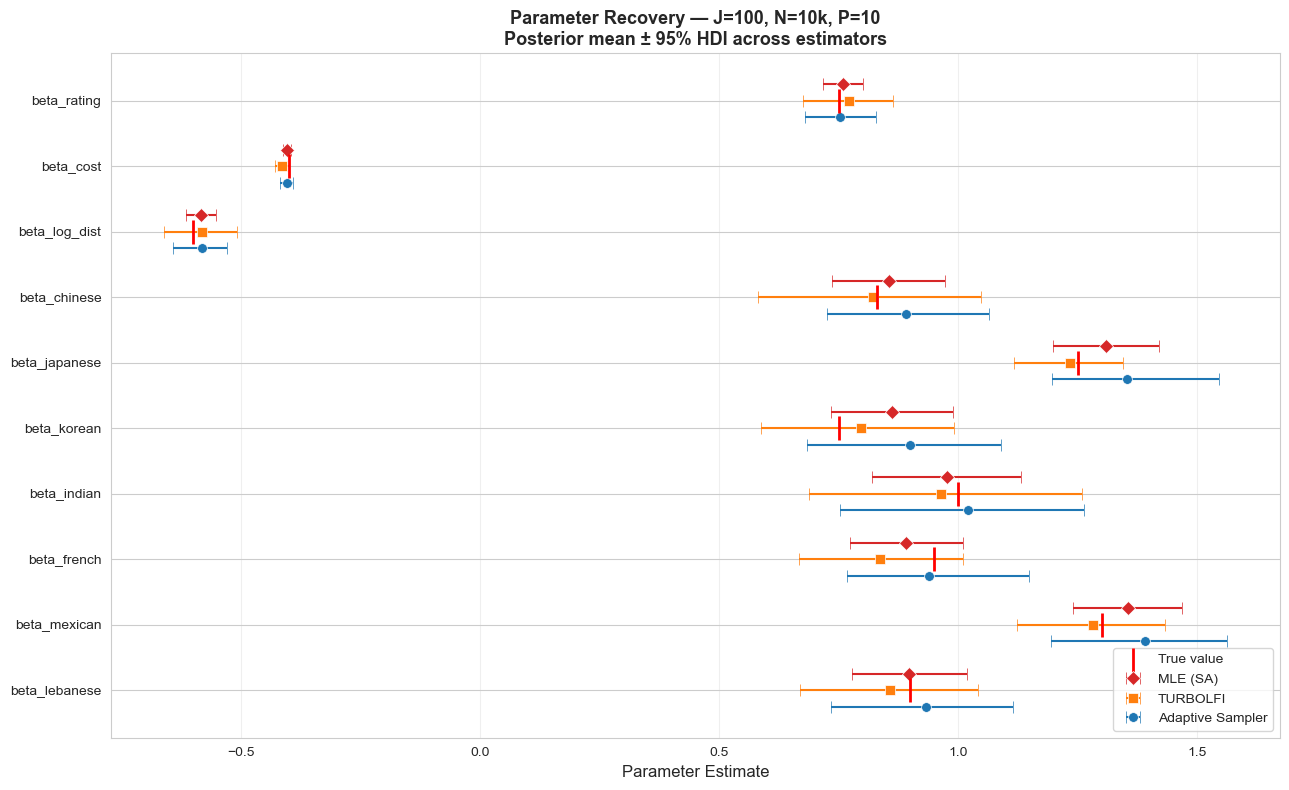

abs_error                           in_hdi                 \
estimator     AdaptiveSampler     MLE TURBOLFI AdaptiveSampler   MLE TURBOLFI   
parameter                                                                       
beta_chinese            0.062  0.0245    0.008            True  True     True   
beta_cost               0.004  0.0032    0.013            True  True     True   
beta_french             0.011  0.0582    0.113            True  True     True   
beta_indian             0.020  0.0233    0.036            True  True     True   
beta_japanese           0.104  0.0588    0.015            True  True     True   
beta_korean             0.149  0.1120    0.048            True  True     True   
beta_lebanese           0.032  0.0017    0.042            True  True     True   
beta_log_dist           0.018  0.0174    0.019            True  True     True   
beta_mexican            0.091  0.0543    0.017            True  True     True   
beta_rating             0.004  0.0093    0.022            True  True     True   

               interval_width                   posterior_mean          \
estimator     AdaptiveSampler     MLE TURBOLFI AdaptiveSampler     MLE   
parameter                                                                
beta_chinese            0.339  0.2344    0.467           0.892  0.8545   
beta_cost               0.027  0.0164    0.029          -0.404 -0.4032   
beta_french             0.381  0.2374    0.343           0.939  0.8918   
beta_indian             0.510  0.3116    0.570           1.020  0.9767   
beta_japanese           0.350  0.2219    0.228           1.354  1.3088   
beta_korean             0.405  0.2558    0.404           0.899  0.8620   
beta_lebanese           0.380  0.2398    0.372           0.932  0.8983   
beta_log_dist           0.112  0.0623    0.153          -0.582 -0.5826   
beta_mexican            0.367  0.2296    0.310           1.391  1.3543   
beta_rating             0.150  0.0842    0.187           0.754  0.7593   

                        
estimator     TURBOLFI  
parameter               
beta_chinese     0.822  
beta_cost       -0.413  
beta_french      0.837  
beta_indian      0.964  
beta_japanese    1.235  
beta_korean      0.798  
beta_lebanese    0.858  
beta_log_dist   -0.581  
beta_mexican     1.283  
beta_rating      0.772

In [6]:
SELECTED_J = 100   # change to 200 or 500
SELECTED_N = 10000 # change to 20000 or 50000

sub = df_all[(df_all['J'] == SELECTED_J) & (df_all['N'] == SELECTED_N)].copy()

if sub.empty:
    print(f"No data for J={SELECTED_J}, N={SELECTED_N}.")
    print("Available configs:")
    print(df_all[['estimator', 'J', 'N']].drop_duplicates().sort_values(['estimator', 'J', 'N']).to_string(index=False))
else:
    estimators = sub['estimator'].unique()
    n_est = len(estimators)
    offsets = np.linspace(-0.25, 0.25, n_est)
    y_labels = PARAM_NAMES_P10
    y_pos = {p: i for i, p in enumerate(y_labels)}

    fig, ax = plt.subplots(figsize=(13, 8))

    for k, est in enumerate(estimators):
        est_data = sub[sub['estimator'] == est]
        color = ESTIMATOR_COLORS.get(est, f'C{k}')
        marker = ESTIMATOR_MARKERS.get(est, 'o')
        label = ESTIMATOR_LABELS.get(est, est)

        for _, row in est_data.iterrows():
            if row['parameter'] not in y_pos:
                continue
            yp = y_pos[row['parameter']] + offsets[k]
            ax.errorbar(
                row['posterior_mean'], yp,
                xerr=[[row['posterior_mean'] - row['hdi_low']],
                      [row['hdi_high'] - row['posterior_mean']]],
                fmt=marker, color=color, markersize=7,
                capsize=4, capthick=1.5, linewidth=1.5,
                ecolor=color, markeredgecolor='white', markeredgewidth=0.5,
                label=label if row['parameter'] == PARAM_NAMES_P10[0] else '_nolegend_'
            )

    # True value markers
    for param, tv in TRUE_VALUES_P10.items():
        if param in y_pos:
            ax.scatter(tv, y_pos[param], marker='|', s=300, color='red',
                       zorder=5, linewidths=2,
                       label='True value' if param == PARAM_NAMES_P10[0] else '_nolegend_')

    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Parameter Estimate', fontsize=12)
    ax.set_title(f'Parameter Recovery — J={SELECTED_J}, N={SELECTED_N//1000}k, P=10\n'
                 f'Posterior mean ± 95% HDI across estimators', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    # Summary table for this config
    pivot = sub.pivot_table(index='parameter', columns='estimator',
                            values=['posterior_mean', 'interval_width', 'in_hdi', 'abs_error'],
                            aggfunc='first')
    display(pivot.round(4))

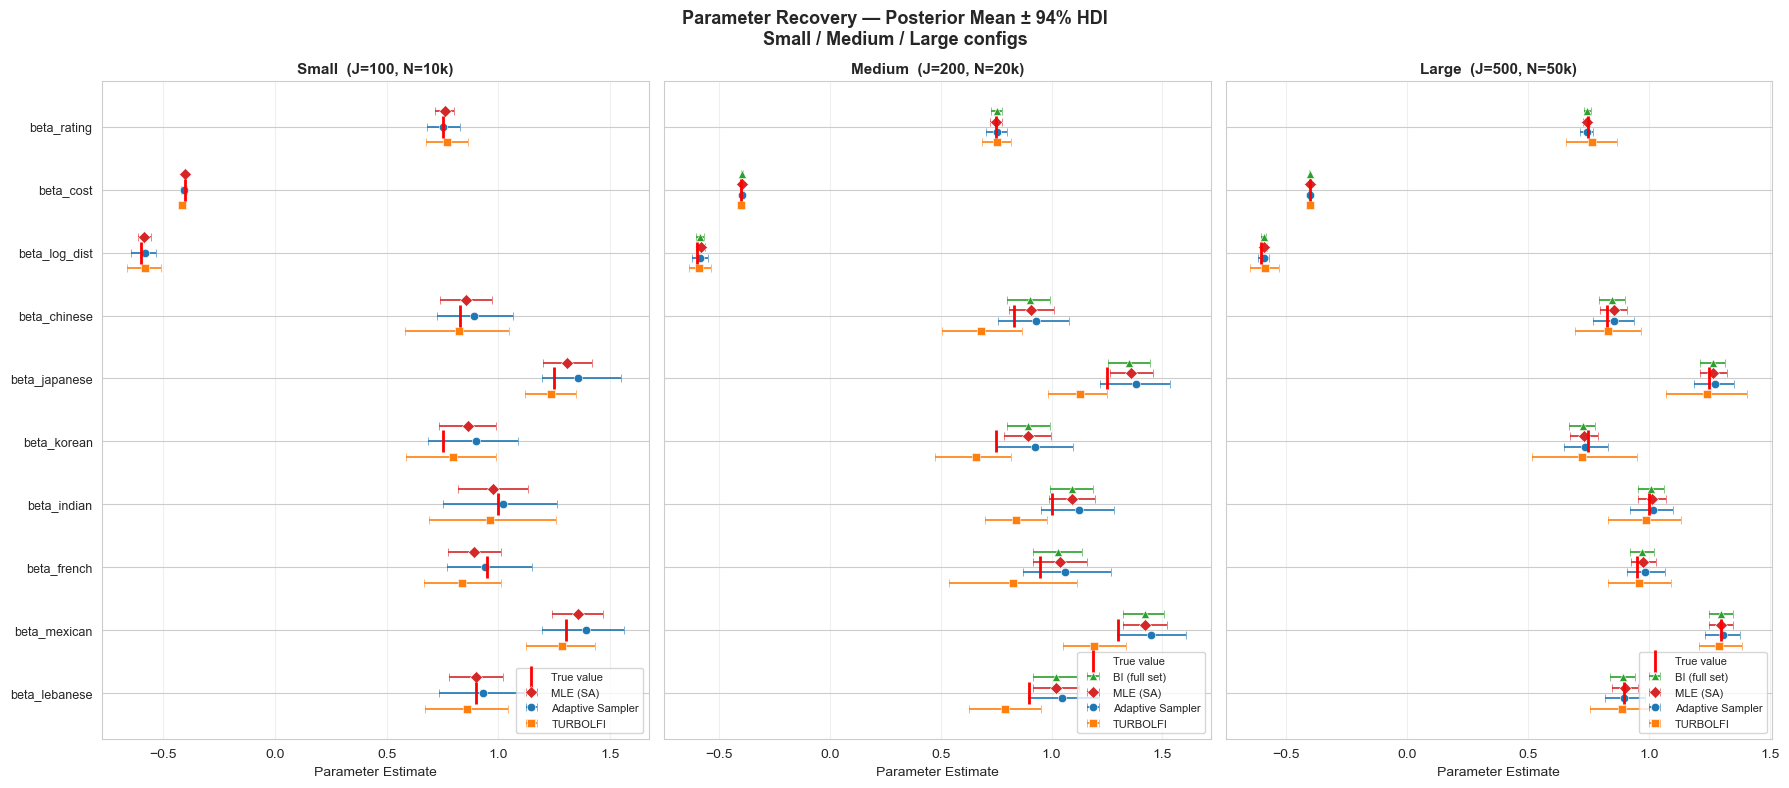

In [7]:

# ── Parameter recovery: 3 configs side-by-side ────────────────────────────────
CONFIGS_3 = [(100, 10000), (200, 20000), (500, 50000)]
CONFIG_TITLES = ['Small  (J=100, N=10k)', 'Medium  (J=200, N=20k)', 'Large  (J=500, N=50k)']

y_labels = PARAM_NAMES_P10
y_pos    = {p: i for i, p in enumerate(y_labels)}

fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)

for ax, (sel_j, sel_n), title in zip(axes, CONFIGS_3, CONFIG_TITLES):
    sub3 = df_all[(df_all['J'] == sel_j) & (df_all['N'] == sel_n)].copy()

    if sub3.empty:
        ax.text(0.5, 0.5, f'No data\nJ={sel_j}, N={sel_n//1000}k',
                ha='center', va='center', transform=ax.transAxes, fontsize=11, color='gray')
        ax.set_title(title, fontsize=11, fontweight='bold')
        continue

    ests3    = [e for e in ['BI', 'MLE', 'AdaptiveSampler', 'TURBOLFI'] if e in sub3['estimator'].unique()]
    offsets3 = np.linspace(-0.25, 0.25, len(ests3))

    for k, est in enumerate(ests3):
        est_data = sub3[sub3['estimator'] == est]
        color    = ESTIMATOR_COLORS.get(est, f'C{k}')
        marker   = ESTIMATOR_MARKERS.get(est, 'o')
        label    = ESTIMATOR_LABELS.get(est, est)
        label_used = False

        for _, row in est_data.iterrows():
            if row['parameter'] not in y_pos:
                continue
            yp = y_pos[row['parameter']] + offsets3[k]
            ax.errorbar(
                row['posterior_mean'], yp,
                xerr=[[row['posterior_mean'] - row['hdi_low']],
                      [row['hdi_high'] - row['posterior_mean']]],
                fmt=marker, color=color, markersize=6,
                capsize=3, capthick=1.2, linewidth=1.2,
                ecolor=color, markeredgecolor='white', markeredgewidth=0.4,
                label=label if not label_used else '_nolegend_'
            )
            label_used = True

    # True value markers
    for param, tv in TRUE_VALUES_P10.items():
        if param in y_pos:
            ax.scatter(tv, y_pos[param], marker='|', s=250, color='red',
                       zorder=5, linewidths=2,
                       label='True value' if param == PARAM_NAMES_P10[0] else '_nolegend_')

    ax.set_yticks(range(len(y_labels)))
    if ax == axes[0]:
        ax.set_yticklabels(y_labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Parameter Estimate', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3, axis='x')

fig.suptitle('Parameter Recovery — Posterior Mean ± 94% HDI\nSmall / Medium / Large configs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


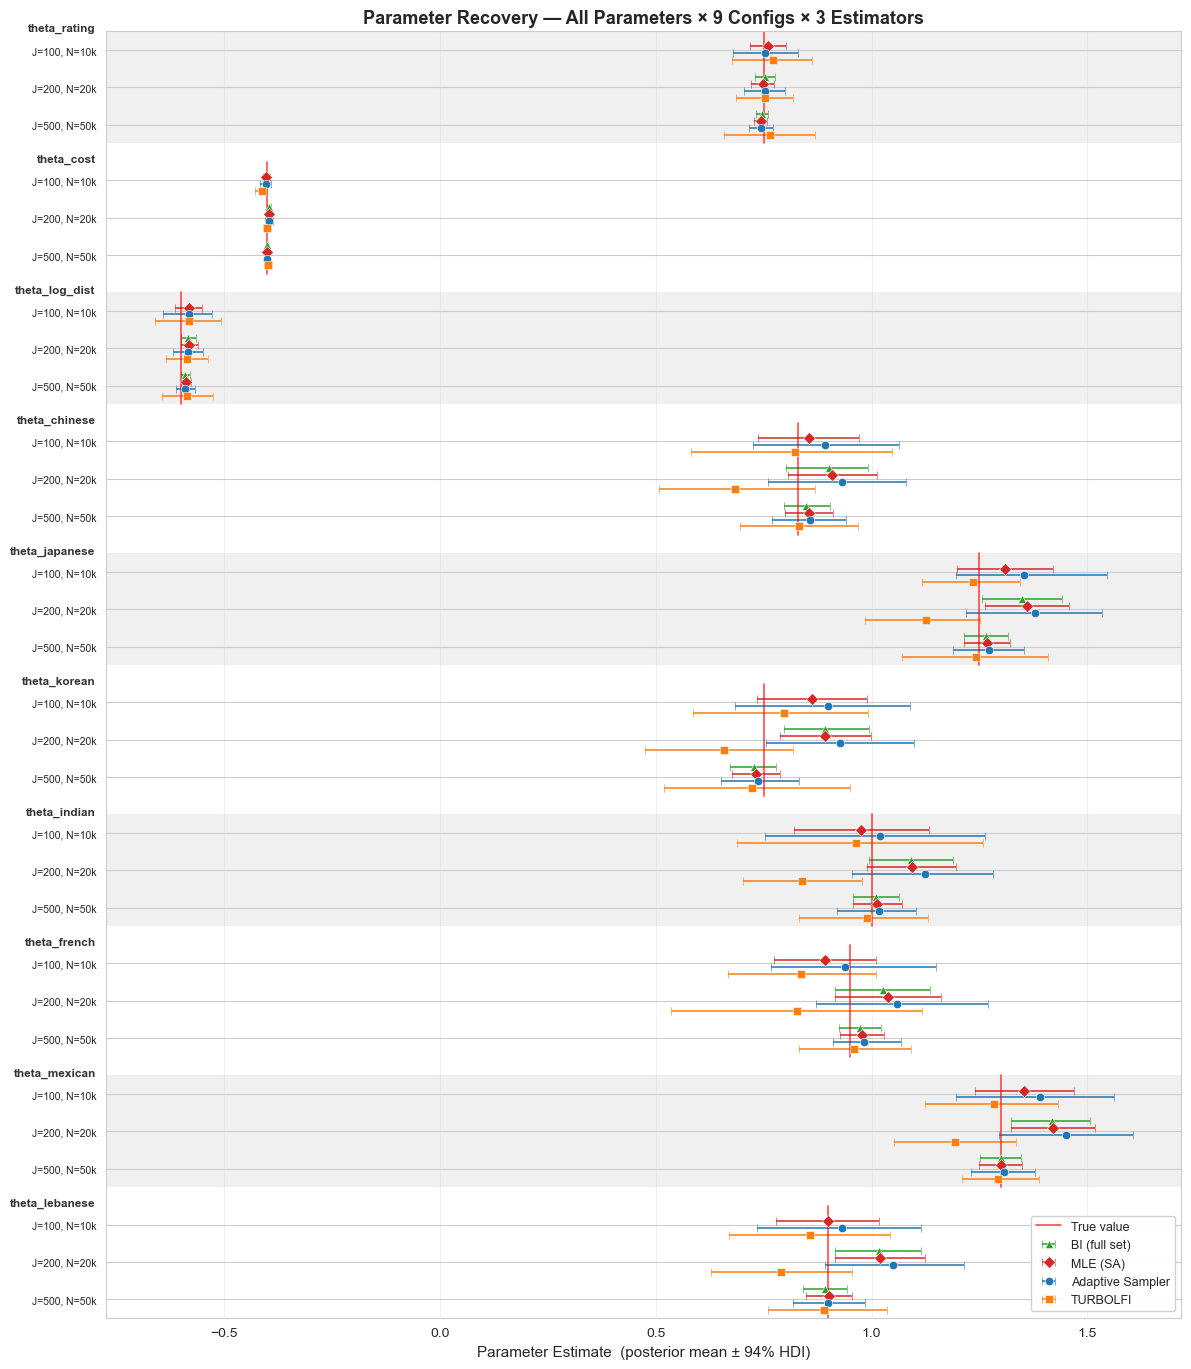

In [8]:

# ── Single unified forest plot: all 10 params × 3 configs × 3 estimators ──────
#
# Layout (approach A):
#   Y-axis rows: 10 parameter groups × (N_CONFIGS data rows + GAP_HEIGHT blank rows)
#   Color + Marker = estimator   |   Row label = config
#   Alternating light shading = parameter group
#
CONFIGS_PLOT  = [(100, 10000), (200, 20000), (500, 50000)]
CONFIG_LABELS = ['J=100, N=10k', 'J=200, N=20k', 'J=500, N=50k']
N_CONFIGS    = len(CONFIG_LABELS)   # number of data rows per parameter group (auto)
GAP_HEIGHT   = 0.5                    # ← blank rows between parameter groups (change this)
GROUP_HEIGHT = N_CONFIGS + GAP_HEIGHT

# Build y-positions and tick info
ytick_pos    = []
ytick_labels = []
param_group_centers = {}   # param → centre y of its data rows

for pi, param in enumerate(PARAM_NAMES_P10):
    base = pi * GROUP_HEIGHT
    param_group_centers[param] = base + (N_CONFIGS - 1) / 2
    for ci, cfg_label in enumerate(CONFIG_LABELS):
        y = base + ci
        ytick_pos.append(y)
        ytick_labels.append(cfg_label)

total_height = len(PARAM_NAMES_P10) * GROUP_HEIGHT - GAP_HEIGHT  # last gap not needed
estimators_u = [e for e in ['BI', 'MLE', 'AdaptiveSampler', 'TURBOLFI'] if e in df_all['estimator'].unique()]
offsets_u     = np.linspace(-0.28, 0.28, len(estimators_u))

fig, ax = plt.subplots(figsize=(12, total_height * 0.4 ))

# ── Alternating shading per parameter group ───────────────────────────────────
for pi in range(len(PARAM_NAMES_P10)):
    if pi % 2 == 0:
        base = pi * GROUP_HEIGHT
        ax.axhspan(base - 0.5, base + N_CONFIGS - 0.5,
                   color='#f0f0f0', zorder=0, linewidth=0)

# ── Plot points ───────────────────────────────────────────────────────────────
for k, est in enumerate(estimators_u):
    color  = ESTIMATOR_COLORS.get(est, f'C{k}')
    marker = ESTIMATOR_MARKERS.get(est, 'o')
    label  = ESTIMATOR_LABELS.get(est, est)
    label_used = False

    for pi, param in enumerate(PARAM_NAMES_P10):
        for ci, (sel_j, sel_n) in enumerate(CONFIGS_PLOT):
            row = df_all[
                (df_all['parameter'] == param) &
                (df_all['estimator'] == est) &
                (df_all['J'] == sel_j) &
                (df_all['N'] == sel_n)
            ]
            if row.empty:
                continue
            row = row.iloc[0]
            yp  = pi * GROUP_HEIGHT + ci + offsets_u[k]
            ax.errorbar(
                row['posterior_mean'], yp,
                xerr=[[row['posterior_mean'] - row['hdi_low']],
                      [row['hdi_high'] - row['posterior_mean']]],
                fmt=marker, color=color, markersize=6,
                capsize=3, capthick=1.1, linewidth=1.1,
                ecolor=color, markeredgecolor='white', markeredgewidth=0.4,
                label=label if not label_used else '_nolegend_'
            )
            label_used = True

# ── True value lines per parameter ───────────────────────────────────────────
for pi, param in enumerate(PARAM_NAMES_P10):
    tv   = TRUE_VALUES_P10[param]
    base = pi * GROUP_HEIGHT
    ax.plot([tv, tv], [base - 0.5, base + N_CONFIGS - 0.5],
            color='red', linewidth=1.2, alpha=0.7,
            label='True value' if pi == 0 else '_nolegend_')

# ── Parameter name annotations on left margin ─────────────────────────────────
for param, cy in param_group_centers.items():
    ax.text(x=-0.01, y=cy-1.58, s=param.replace('beta_', 'theta_'),
            transform=ax.get_yaxis_transform(),
            ha='right', va='center', fontsize=8.5, fontweight='bold', color='#333333')

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_yticks(ytick_pos)
ax.set_yticklabels(ytick_labels, fontsize=7.5)
ax.invert_yaxis()
ax.set_ylim(total_height - 0.5, -0.5)   # remove top/bottom padding
ax.set_xlabel('Parameter Estimate  (posterior mean ± 94% HDI)', fontsize=11)
ax.set_title('Parameter Recovery — All Parameters × 9 Configs × 3 Estimators',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.25, axis='x')

plt.tight_layout()
# plt.savefig('plots/forest_plot_all_params_9_configs.png', dpi=600, bbox_inches='tight')
plt.show()


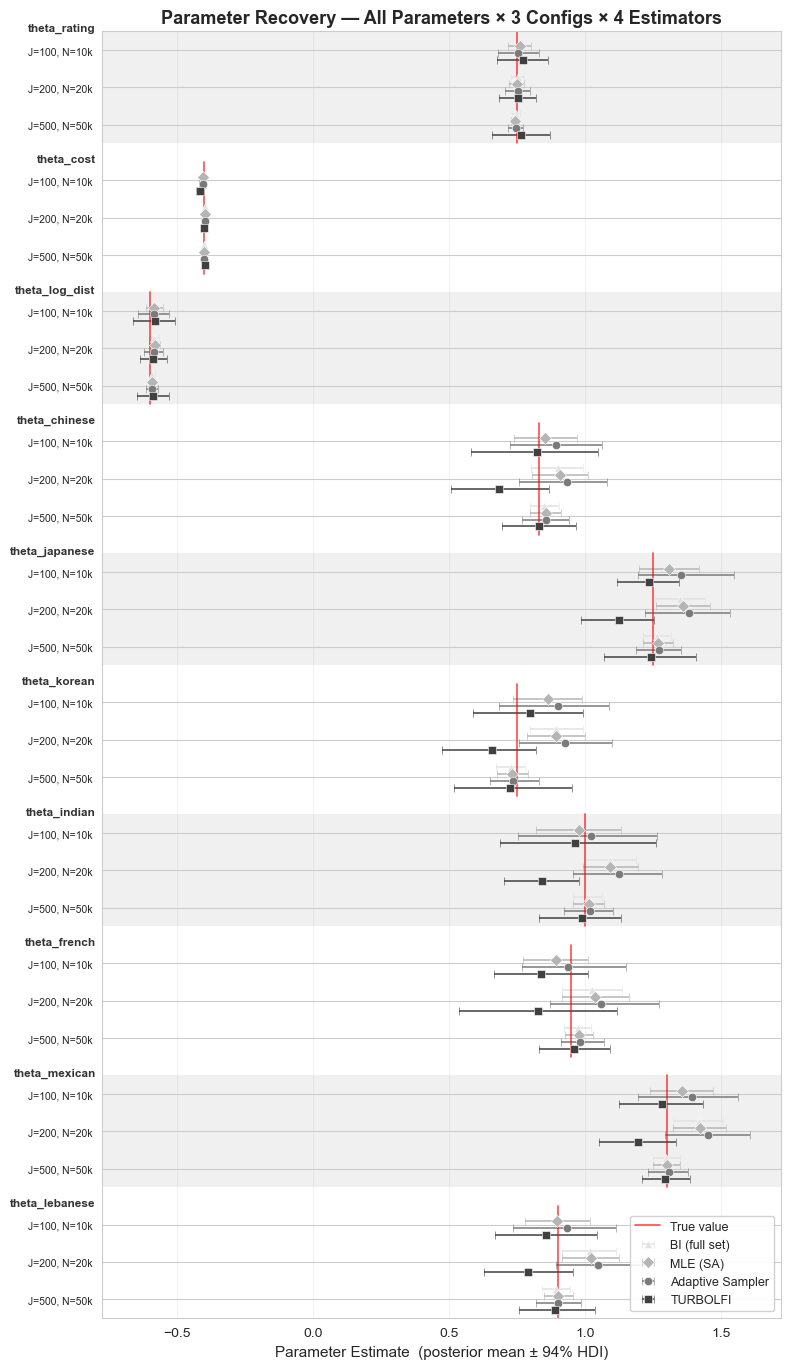

In [9]:
# ── Same forest plot but with palette-based shadings instead of distinct colors ────
#
# Uses a seaborn palette to create subtle shading differences between estimators
# rather than contrasting colors. Hue varies smoothly while preserving readability.
#

PALETTE_NAME = 'Greys'  # Change to 'Greys', 'Purples', 'Greens', 'Oranges', 'Reds', etc.

# Generate colors from the palette
palette_colors = sns.color_palette(PALETTE_NAME, n_colors=len(estimators_u))
estimator_colors_palette = {est: palette_colors[k] for k, est in enumerate(estimators_u)}

# Same setup as before
fig, ax = plt.subplots(figsize=(8, total_height * 0.4))

# ── Alternating shading per parameter group ───────────────────────────────────
for pi in range(len(PARAM_NAMES_P10)):
    if pi % 2 == 0:
        base = pi * GROUP_HEIGHT
        ax.axhspan(base - 0.5, base + N_CONFIGS - 0.5,
                   color='#f0f0f0', zorder=0, linewidth=0)

# ── Plot points with palette colors ────────────────────────────────────────────
for k, est in enumerate(estimators_u):
    color  = estimator_colors_palette[est]
    marker = ESTIMATOR_MARKERS.get(est, 'o')
    label  = ESTIMATOR_LABELS.get(est, est)
    label_used = False

    for pi, param in enumerate(PARAM_NAMES_P10):
        for ci, (sel_j, sel_n) in enumerate(CONFIGS_PLOT):
            row = df_all[
                (df_all['parameter'] == param) &
                (df_all['estimator'] == est) &
                (df_all['J'] == sel_j) &
                (df_all['N'] == sel_n)
            ]
            if row.empty:
                continue
            row = row.iloc[0]
            yp  = pi * GROUP_HEIGHT + ci + offsets_u[k]
            ax.errorbar(
                row['posterior_mean'], yp,
                xerr=[[row['posterior_mean'] - row['hdi_low']],
                      [row['hdi_high'] - row['posterior_mean']]],
                fmt=marker, color=color, markersize=6,
                capsize=3, capthick=1.1, linewidth=1.1,
                ecolor=color, markeredgecolor='white', markeredgewidth=0.4,
                label=label if not label_used else '_nolegend_'
            )
            label_used = True

# ── True value lines per parameter ───────────────────────────────────────────
for pi, param in enumerate(PARAM_NAMES_P10):
    tv   = TRUE_VALUES_P10[param]
    base = pi * GROUP_HEIGHT
    ax.plot([tv, tv], [base - 0.5, base + N_CONFIGS - 0.5],
            color='red', linewidth=1.2, alpha=0.7,
            label='True value' if pi == 0 else '_nolegend_')

# ── Parameter name annotations on left margin ─────────────────────────────────
for param, cy in param_group_centers.items():
    ax.text(x=-0.01, y=cy-1.58, s=param.replace('beta_', 'theta_'),
            transform=ax.get_yaxis_transform(),
            ha='right', va='center', fontsize=8.5, fontweight='bold', color='#333333')

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_yticks(ytick_pos)
ax.set_yticklabels(ytick_labels, fontsize=7.5)
ax.invert_yaxis()
ax.set_ylim(total_height - 0.5, -0.5)   # remove top/bottom padding
ax.set_xlabel('Parameter Estimate  (posterior mean ± 94% HDI)', fontsize=11)
ax.set_title(f'Parameter Recovery — All Parameters × 3 Configs × 4 Estimators',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.25, axis='x')

plt.tight_layout()
plt.show()


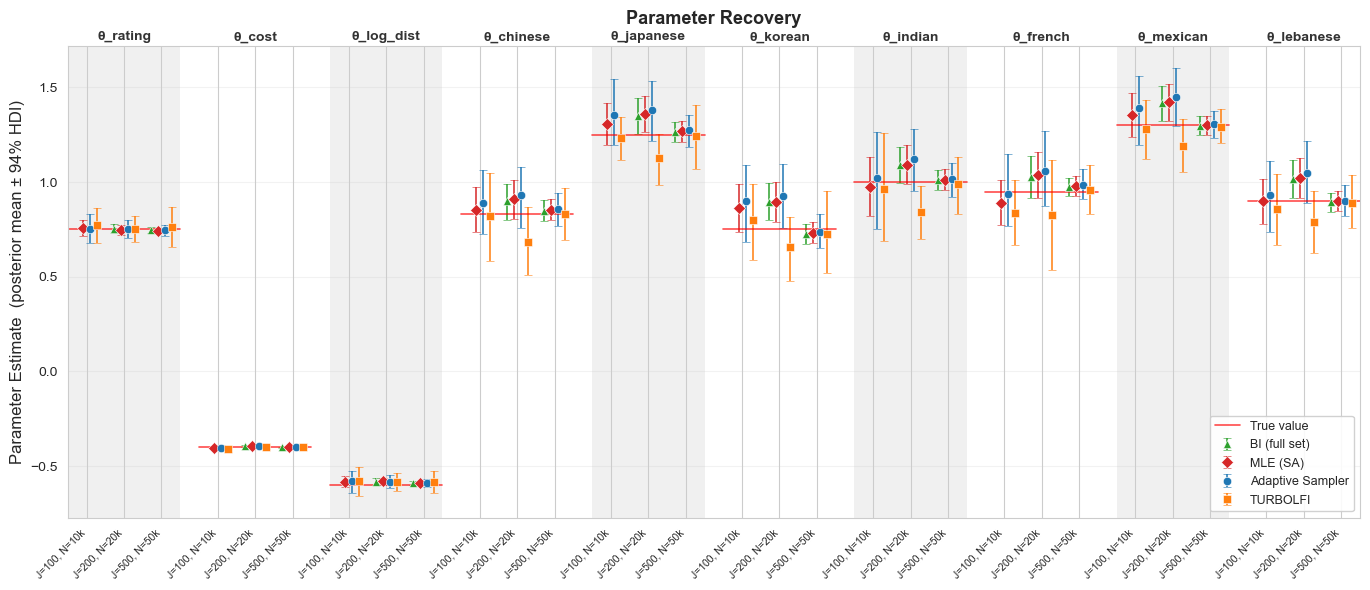

In [10]:

# ── Rotated forest plot: parameters & configs on X-axis, recovery on Y-axis ────
#
# Same layout as before but transposed:
#   X-axis: parameter groups × config rows (similar to Y-axis in previous plot)
#   Y-axis: posterior mean ± 94% HDI
#   Colors + Markers: estimators (same as before)
#   Vertical bands: parameter groups (alternating shading)

CONFIGS_ROTATED  = [(100, 10000), (200, 20000), (500, 50000)]
CONFIG_LABELS_R  = ['J=100, N=10k', 'J=200, N=20k', 'J=500, N=50k']
N_CONFIGS_R      = len(CONFIG_LABELS_R)
GAP_HEIGHT_R     = 0.5
GROUP_HEIGHT_R   = N_CONFIGS_R + GAP_HEIGHT_R

# Build x-positions and tick info
xtick_pos    = []
xtick_labels = []
param_group_centers_x = {}   # param → centre x of its data rows

for pi, param in enumerate(PARAM_NAMES_P10):
    base = pi * GROUP_HEIGHT_R
    param_group_centers_x[param] = base + (N_CONFIGS_R - 1) / 2
    for ci, cfg_label in enumerate(CONFIG_LABELS_R):
        x = base + ci
        xtick_pos.append(x)
        xtick_labels.append(cfg_label)

total_width_r = len(PARAM_NAMES_P10) * GROUP_HEIGHT_R - GAP_HEIGHT_R
estimators_r  = [e for e in ['BI', 'MLE', 'AdaptiveSampler', 'TURBOLFI'] if e in df_all['estimator'].unique()]
offsets_r     = np.linspace(-0.28, 0.28, len(estimators_r))

fig, ax = plt.subplots(figsize=(total_width_r * 0.4, 6))

# ── Alternating shading per parameter group (vertical bands) ──────────────────
for pi in range(len(PARAM_NAMES_P10)):
    if pi % 2 == 0:
        base = pi * GROUP_HEIGHT_R
        ax.axvspan(base - 0.5, base + N_CONFIGS_R - 0.5,
                   color='#f0f0f0', zorder=0, linewidth=0)

# ── Plot points ───────────────────────────────────────────────────────────────
for k, est in enumerate(estimators_r):
    color  = ESTIMATOR_COLORS.get(est, f'C{k}')
    marker = ESTIMATOR_MARKERS.get(est, 'o')
    label  = ESTIMATOR_LABELS.get(est, est)
    label_used = False

    for pi, param in enumerate(PARAM_NAMES_P10):
        for ci, (sel_j, sel_n) in enumerate(CONFIGS_ROTATED):
            row = df_all[
                (df_all['parameter'] == param) &
                (df_all['estimator'] == est) &
                (df_all['J'] == sel_j) &
                (df_all['N'] == sel_n)
            ]
            if row.empty:
                continue
            row = row.iloc[0]
            xp  = pi * GROUP_HEIGHT_R + ci + offsets_r[k]
            ax.errorbar(
                xp,
                row['posterior_mean'],
                yerr=[[row['posterior_mean'] - row['hdi_low']],
                      [row['hdi_high'] - row['posterior_mean']]],
                fmt=marker, color=color, markersize=6,
                capsize=3, capthick=1.1, linewidth=1.1,
                ecolor=color, markeredgecolor='white', markeredgewidth=0.4,
                label=label if not label_used else '_nolegend_'
            )
            label_used = True

# ── True value lines per parameter (horizontal bands) ───────────────────────
for pi, param in enumerate(PARAM_NAMES_P10):
    tv   = TRUE_VALUES_P10[param]
    base = pi * GROUP_HEIGHT_R
    ax.plot([base - 0.5, base + N_CONFIGS_R - 0.5], [tv, tv],
            color='red', linewidth=1.2, alpha=0.7,
            label='True value' if pi == 0 else '_nolegend_')

# ── Parameter name annotations on top (vertical text) ────────────────────────
for param, cx in param_group_centers_x.items():
    ax.text(x=cx, y=ax.get_ylim()[1]*1.01, s=param.replace('beta_', 'θ_'),
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_labels, fontsize=7.5, rotation=45, ha='right')
ax.set_xlim(-0.5, total_width_r - 0.5)
ax.set_ylabel('Parameter Estimate  (posterior mean ± 94% HDI)', fontsize=12)
ax.set_title('Parameter Recovery',
             fontsize=13, fontweight='bold', y=1.03)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.25, axis='y')

plt.tight_layout()
# plt.savefig('plots/forest_plot_all_params_9_configs_rotated.png', dpi=1400, bbox_inches='tight')
plt.show()


In [11]:

# ── Posterior mean + 94% HDI: all params × 3 configs × 3 estimators ──────────
CONFIGS_DISPLAY   = [(100, 10000), (200, 20000), (500, 50000)]
ESTIMATORS_DISPLAY = ['BI', 'AdaptiveSampler', 'TURBOLFI']

rows = []
for param in PARAM_NAMES_P10:
    tv = TRUE_VALUES_P10[param]
    for est in ESTIMATORS_DISPLAY:
        for sel_j, sel_n in CONFIGS_DISPLAY:
            r = df_all[
                (df_all['parameter'] == param) &
                (df_all['estimator'] == est) &
                (df_all['J'] == sel_j) &
                (df_all['N'] == sel_n)
            ]
            if r.empty:
                rows.append({'parameter': param, 'estimator': est,
                             'J': sel_j, 'N': sel_n,
                             'true_value': tv,
                             'posterior_mean': None, 'hdi_low': None,
                             'hdi_high': None, 'interval_width': None,
                             'in_hdi': None})
            else:
                r = r.iloc[0]
                rows.append({'parameter': param,
                             'estimator': ESTIMATOR_LABELS.get(est, est),
                             'J': sel_j, 'N': int(sel_n) // 1000,
                             'true_value': tv,
                             'posterior_mean': r['posterior_mean'],
                             'hdi_low':  r['hdi_low'],
                             'hdi_high': r['hdi_high'],
                             'interval_width': r['interval_width'],
                             'in_hdi': r['in_hdi']})

df_display = pd.DataFrame(rows)

# Build a multi-column display: one column group per (estimator, config)
pivot_mean  = df_display.pivot_table(index='parameter', columns=['estimator', 'J', 'N'],
                                     values='posterior_mean')
pivot_low   = df_display.pivot_table(index='parameter', columns=['estimator', 'J', 'N'],
                                     values='hdi_low')
pivot_high  = df_display.pivot_table(index='parameter', columns=['estimator', 'J', 'N'],
                                     values='hdi_high')
pivot_in    = df_display.pivot_table(index='parameter', columns=['estimator', 'J', 'N'],
                                     values='interval_width')

# Reorder rows
pivot_mean  = pivot_mean.reindex(PARAM_NAMES_P10)
pivot_low   = pivot_low.reindex(PARAM_NAMES_P10)
pivot_high  = pivot_high.reindex(PARAM_NAMES_P10)
pivot_in    = pivot_in.reindex(PARAM_NAMES_P10)

# True values column
true_col = pd.Series({p: TRUE_VALUES_P10[p] for p in PARAM_NAMES_P10}, name='true')

print("POSTERIOR MEAN")
display(pd.concat([true_col, pivot_mean], axis=1)
        .style.format('{:.4f}', na_rep='—'))

print("94% HDI LOW")
display(pivot_low.style.format('{:.4f}', na_rep='—'))

print("94% HDI HIGH")
display(pivot_high.style.format('{:.4f}', na_rep='—'))

print("IN 94% HDI  (true value inside interval?)")
display(pivot_in.style.format('{:.4f}', na_rep='—'))


POSTERIOR MEAN


,true,"('Adaptive Sampler', 100, 10)","('Adaptive Sampler', 200, 20)","('Adaptive Sampler', 500, 50)","('BI (full set)', 200, 20)","('BI (full set)', 500, 50)","('TURBOLFI', 100, 10)","('TURBOLFI', 200, 20)","('TURBOLFI', 500, 50)"
beta_rating,0.7500,0.7540,0.7530,0.7450,0.7520,0.7460,0.7720,0.7540,0.7650
beta_cost,-0.4000,-0.4040,-0.3960,-0.4010,-0.3960,-0.4010,-0.4130,-0.4010,-0.3980
beta_log_dist,-0.6000,-0.5820,-0.5830,-0.5900,-0.5830,-0.5900,-0.5810,-0.5870,-0.5870
beta_chinese,0.8300,0.8920,0.9320,0.8580,0.9010,0.8490,0.8220,0.6840,0.8320
beta_japanese,1.2500,1.3540,1.3800,1.2730,1.3490,1.2650,1.2350,1.1260,1.2420
beta_korean,0.7500,0.8990,0.9260,0.7360,0.8930,0.7280,0.7980,0.6590,0.7230
beta_indian,1.0000,1.0200,1.1230,1.0180,1.0910,1.0100,0.9640,0.8400,0.9890
beta_french,0.9500,0.9390,1.0600,0.9830,1.0270,0.9740,0.8370,0.8280,0.9600
beta_mexican,1.3000,1.3910,1.4500,1.3070,1.4190,1.2990,1.2830,1.1930,1.2920
beta_lebanese,0.9000,0.9320,1.0490,0.9000,1.0180,0.8930,0.8580,0.7900,0.8890


94% HDI LOW


94% HDI HIGH


IN 94% HDI  (true value inside interval?)


## 6. Cross-Config Recovery: Effect of J and N

For a chosen parameter, visualize how posterior mean and interval width change as J and N vary — separately for each estimator.

**Top row**: posterior mean vs J (with N as line style) — red band = true value ± 5%  
**Bottom row**: HDI interval width vs J

Text(0.5, 1.0, 'Forest Plot: beta_rating\nAll configs x 4 estimators  |  95% HDI')

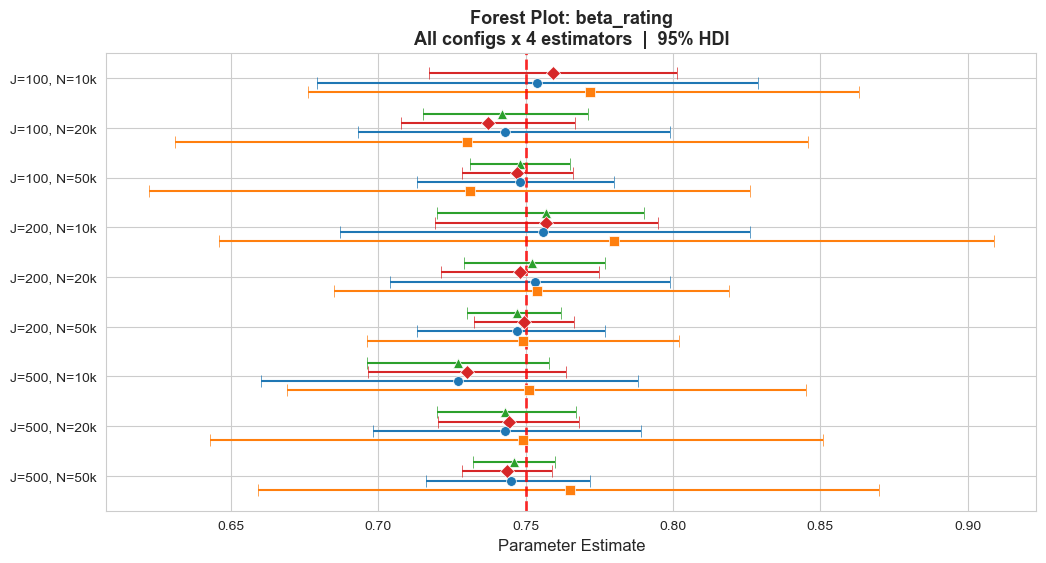

In [12]:
#  Forest plot: all (J,N) configs x 4 estimators for a chosen parameter 
PARAM_FOREST = 'beta_rating'   # change to any PARAM_NAMES_P10 entry

param_df = df_all[df_all['parameter'] == PARAM_FOREST].copy()
true_val = TRUE_VALUES_P10[PARAM_FOREST]

# Build sorted list of (J,N) configs present in data
configs = sorted(
    param_df[['J', 'N']].drop_duplicates().itertuples(index=False),
    key=lambda x: (x.J, x.N)
)
config_labels = [f"J={c.J}, N={c.N//1000}k" for c in configs]
n_configs = len(configs)
estimators = [e for e in ['BI', 'MLE', 'AdaptiveSampler', 'TURBOLFI'] if e in param_df['estimator'].unique()]
n_est = len(estimators)

offsets = np.linspace(-0.28, 0.28, n_est)
fig, ax = plt.subplots(figsize=(12, max(5, n_configs * 0.55 + 1)))

for k, est in enumerate(estimators):
    color = ESTIMATOR_COLORS.get(est, f'C{k}')
    marker = ESTIMATOR_MARKERS.get(est, 'o')
    label = ESTIMATOR_LABELS.get(est, est)

    for i, cfg in enumerate(configs):
        row = param_df[(param_df['estimator'] == est) &
                       (param_df['J'] == cfg.J) &
                       (param_df['N'] == cfg.N)]
        if row.empty:
            continue
        row = row.iloc[0]
        yp = i + offsets[k]
        ax.errorbar(
            row['posterior_mean'], yp,
            xerr=[[row['posterior_mean'] - row['hdi_low']],
                  [row['hdi_high'] - row['posterior_mean']]],
            fmt=marker, color=color, markersize=7,
            capsize=4, capthick=1.5, linewidth=1.5,
            ecolor=color, markeredgecolor='white', markeredgewidth=0.5,
            label=label if i == 0 else '_nolegend_'
        )

ax.axvline(true_val, color='red', linestyle='--', linewidth=2,
           label=f'True = {true_val}', alpha=0.8)

ax.set_yticks(range(n_configs))
ax.set_yticklabels(config_labels, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Parameter Estimate', fontsize=12)
ax.set_title(f'Forest Plot: {PARAM_FOREST}\nAll configs x 4 estimators  |  95% HDI',
             fontsize=13, fontweight='bold')

### 6b. T-score Forest Plot — Signal vs. Noise

Beyond asking *"is the true value inside the HDI?"* (a binary pass/fail), we want to know **how much the posterior mean has drifted from the truth relative to posterior uncertainty**.

We define a **t-score** (standardised deviation from truth):

$$t = \frac{\hat{\mu} - \theta_{\text{true}}}{\hat{\sigma}}$$

where $\hat{\mu}$ is the posterior mean and $\hat{\sigma}$ is the posterior standard deviation.

**Interpretation:**
| $|t|$ | Meaning |
|---|---|
| $< 1.645$ | Good — bias is within a 90% two-tailed band |
| $1.645$–$1.96$ | Marginal — approaching the 95% significance threshold |
| $> 1.96$ | Significant bias — the posterior mean deviates from truth by more than 1.96 posterior SDs (equivalent to rejecting $H_0: \hat{\mu} = \theta_{\text{true}}$ at the 5% level) |

Unlike HDI coverage, the t-score is **continuous** and reveals *degrees* of miscalibration.  
A large $|t|$ means the estimator confidently points in the wrong direction.

**SD sources per estimator:**
- **TURBOLFI** → `std_error` (MCMC SE reported directly)  
- **Adaptive Sampler** → `sd` (ArviZ posterior SD)  
- **BI** → derived as $\hat{\sigma} \approx \text{interval\_width} / (2 \times z_{0.97}) \approx \text{interval\_width} / 3.76$   (94 % HDI, normal approximation)


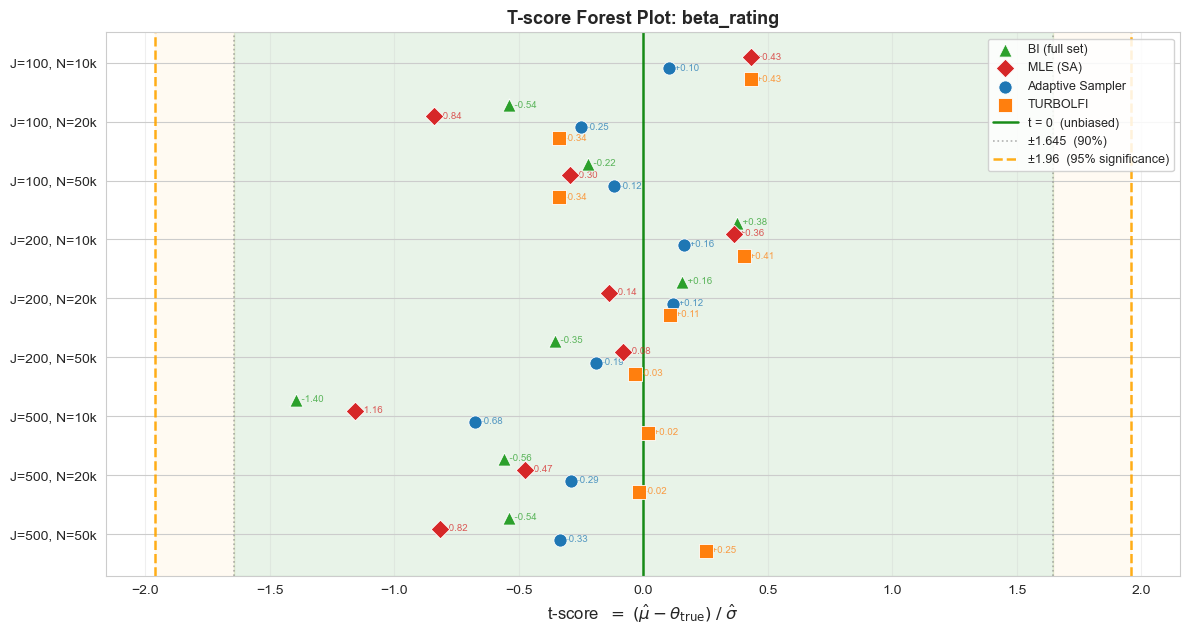

In [13]:

# ── T-score Forest Plot: PARAM_FOREST across all configs x estimators ─────────
# t = (posterior_mean − true_value) / posterior_sd
# |t| < 1 → excellent  |  |t| < 2 → acceptable  |  |t| > 2 → significant bias

param_df_t = df_all[df_all['parameter'] == PARAM_FOREST].copy()
param_df_t['t_score'] = (
    (param_df_t['posterior_mean'] - param_df_t['true_value'])
    / param_df_t['posterior_sd']
)

# Sorted configs
configs_t = sorted(
    param_df_t[['J', 'N']].drop_duplicates().itertuples(index=False),
    key=lambda x: (x.J, x.N)
)
config_labels_t = [f"J={c.J}, N={c.N//1000}k" for c in configs_t]
n_configs_t     = len(configs_t)
estimators_t    = [e for e in ['BI', 'MLE', 'AdaptiveSampler', 'TURBOLFI']
                   if e in param_df_t['estimator'].unique()]
n_est_t         = len(estimators_t)

offsets_t = np.linspace(-0.28, 0.28, n_est_t)

fig, ax = plt.subplots(figsize=(12, max(5, n_configs_t * 0.55 + 1.5)))

for k, est in enumerate(estimators_t):
    color  = ESTIMATOR_COLORS.get(est, f'C{k}')
    marker = ESTIMATOR_MARKERS.get(est, 'o')
    label  = ESTIMATOR_LABELS.get(est, est)
    label_used = False  # track whether legend entry has been added

    for i, cfg in enumerate(configs_t):
        row = param_df_t[
            (param_df_t['estimator'] == est) &
            (param_df_t['J'] == cfg.J) &
            (param_df_t['N'] == cfg.N)
        ]
        if row.empty:
            continue
        row = row.iloc[0]
        yp  = i + offsets_t[k]
        ax.scatter(
            row['t_score'], yp,
            marker=marker, color=color, s=90, zorder=4,
            edgecolors='white', linewidths=0.6,
            label=label if not label_used else '_nolegend_'
        )
        label_used = True
        # small text annotation next to the point
        ax.text(row['t_score'], yp, f"  {row['t_score']:+.2f}",
                va='center', ha='left', fontsize=7, color=color, alpha=0.75)

# ── Shaded acceptance zone ────────────────────────────────────────────────────
ax.axvspan(-1.645,  1.645, alpha=0.09, color='green',  zorder=0)  # |t| < 1.645  (90%)
ax.axvspan(-1.96, -1.645,  alpha=0.05, color='orange', zorder=0)  # 1.645 < |t| < 1.96
ax.axvspan( 1.645,  1.96,  alpha=0.05, color='orange', zorder=0)

# ── Reference lines ───────────────────────────────────────────────────────────
ax.axvline(0,      color='green',  linestyle='-',  linewidth=1.8, alpha=0.9,
           label='t = 0  (unbiased)')
ax.axvline( 1.645, color='gray',   linestyle=':',  linewidth=1.2, alpha=0.6,
           label='±1.645  (90%)')
ax.axvline(-1.645, color='gray',   linestyle=':',  linewidth=1.2, alpha=0.6,
           label='_nolegend_')
ax.axvline( 1.96,  color='orange', linestyle='--', linewidth=1.8, alpha=0.9,
           label='±1.96  (95% significance)')
ax.axvline(-1.96,  color='orange', linestyle='--', linewidth=1.8, alpha=0.9,
           label='_nolegend_')

ax.set_yticks(range(n_configs_t))
ax.set_yticklabels(config_labels_t, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel(r't-score  $=\;(\hat{\mu} - \theta_{\rm true})\;/\;\hat{\sigma}$',
              fontsize=12)
ax.set_title(
    f'T-score Forest Plot: {PARAM_FOREST}',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='best', fontsize=9, framealpha=0.85)
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
# plt.savefig(f'plots/forest_plot_t_score_{PARAM_FOREST}_all_configs.png', dpi=300)
plt.show()


## 7. Overall Statistics and Coverage Summary

Aggregate per `(estimator, J, N)`:
- **Coverage** — % of P=10 parameters with true value inside 95% HDI  
- **RMSE** — root mean squared error of posterior means  
- **MAE** — mean absolute error of posterior means  
- **Mean HDI width** — average interval width across parameters

In [14]:
agg = df_all.groupby(['estimator', 'J', 'N']).agg(
    coverage    = ('in_hdi',         'mean'),
    rmse        = ('sq_error',        lambda x: np.sqrt(np.mean(x))),
    mae         = ('abs_error',       'mean'),
    mean_width  = ('interval_width',  'mean'),
    mean_rel_w  = ('relative_width',  lambda x: np.nanmean(x)),
    n_params    = ('parameter',       'count'),
).reset_index()

agg['coverage_pct'] = (agg['coverage'] * 100).round(1)
agg['rmse']  = agg['rmse'].round(4)
agg['mae']   = agg['mae'].round(4)
agg['mean_width'] = agg['mean_width'].round(4)
agg['mean_rel_w'] = agg['mean_rel_w'].round(3)

print("=" * 75)
print("AGGREGATED METRICS BY ESTIMATOR x CONFIG")
print("=" * 75)
display(agg.sort_values(['J', 'N', 'estimator'])
            [['estimator', 'J', 'N', 'n_params', 'coverage_pct', 'rmse', 'mae', 'mean_width', 'mean_rel_w']])


AGGREGATED METRICS BY ESTIMATOR x CONFIG


,estimator,J,N,n_params,coverage_pct,rmse,mae,mean_width,mean_rel_w
0,AdaptiveSampler,100,10000,10,100.0,0.0686,0.0495,0.3021,0.330
17,MLE,100,10000,10,100.0,0.0489,0.0363,0.1893,0.206
26,TURBOLFI,100,10000,10,100.0,0.0444,0.0333,0.3063,0.344
1,AdaptiveSampler,100,20000,10,100.0,0.0292,0.0206,0.2237,0.244
9,BI,100,20000,10,100.0,0.0255,0.0188,0.1239,0.135
18,MLE,100,20000,10,100.0,0.0275,0.0197,0.1330,0.145
27,TURBOLFI,100,20000,10,100.0,0.0374,0.0289,0.2701,0.305
2,AdaptiveSampler,100,50000,10,100.0,0.0193,0.0144,0.1393,0.152
10,BI,100,50000,10,100.0,0.0195,0.0146,0.0810,0.088
19,MLE,100,50000,10,100.0,0.0164,0.0136,0.0841,0.092


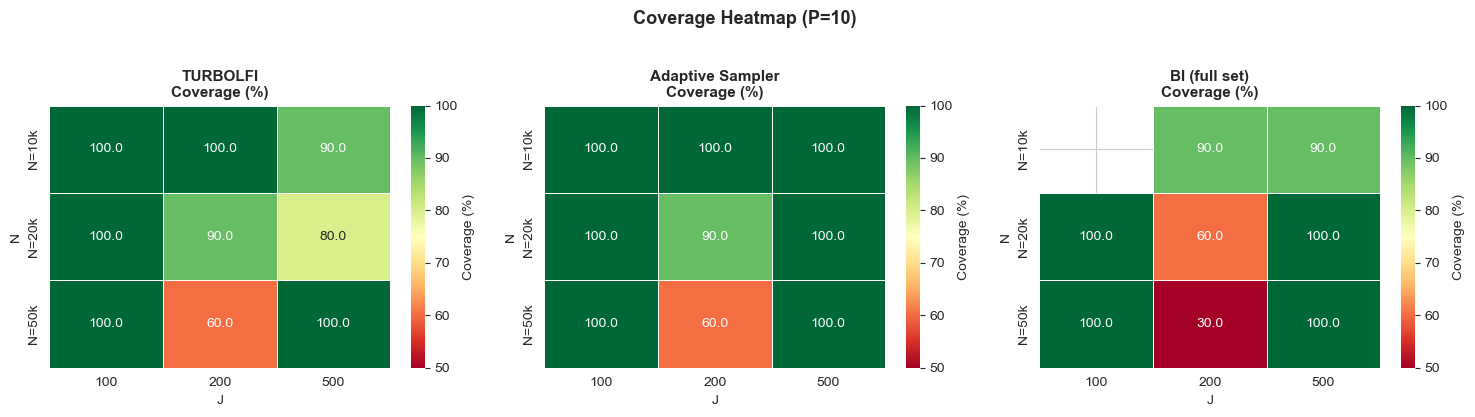

In [15]:
#  Coverage heatmaps per estimator 
estimators_present = [e for e in ['TURBOLFI', 'AdaptiveSampler', 'BI'] if e in agg['estimator'].unique()]
n_est = len(estimators_present)
fig, axes = plt.subplots(1, n_est, figsize=(5 * n_est, 4))
if n_est == 1:
    axes = [axes]

for ax, est in zip(axes, estimators_present):
    sub = agg[agg['estimator'] == est]
    if sub.empty:
        ax.set_visible(False)
        continue
    pivot = sub.pivot(index='N', columns='J', values='coverage_pct')
    pivot.index = [f"N={n//1000}k" for n in pivot.index]
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
                vmin=50, vmax=100, ax=ax,
                cbar_kws={'label': 'Coverage (%)'},
                linewidths=0.5)
    ax.set_title(f'{ESTIMATOR_LABELS.get(est, est)}\nCoverage (%)', fontsize=11, fontweight='bold')
    ax.set_xlabel('J', fontsize=10)
    ax.set_ylabel('N', fontsize=10)

plt.suptitle('Coverage Heatmap (P=10)', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 8. Comprehensive Comparison — Parameter-Level Detail

For a chosen `(J, N)` config: parameter-by-parameter tables for **absolute error**, **relative error (%)**, and **relative HDI width** across the three estimators, with colour-gradient highlighting (green = better).

Then summary statistics (mean / median / max abs error, mean rel error, mean rel width) per estimator x config.

In [16]:
COMP_J = 100    # ← change to 200 or 500
COMP_N = 10000  # ← change to 20000 or 50000

ESTIMATOR_ORDER = ['MLE', 'TURBOLFI', 'AdaptiveSampler', 'BI']

sub_comp = df_all[(df_all['J'] == COMP_J) & (df_all['N'] == COMP_N)].copy()

if sub_comp.empty:
    print(f"No data for J={COMP_J}, N={COMP_N}. Available:")
    print(df_all[['estimator', 'J', 'N']].drop_duplicates().sort_values(['estimator', 'J', 'N']).to_string(index=False))
else:
    # Derived columns
    sub_comp['rel_error_pct'] = ((sub_comp['posterior_mean'] - sub_comp['true_value'])
                                 / sub_comp['true_value'].abs() * 100)
    sub_comp['abs_rel_error_pct'] = sub_comp['rel_error_pct'].abs()
    sub_comp['signed_error'] = sub_comp['posterior_mean'] - sub_comp['true_value']

    est_cols = [e for e in ESTIMATOR_ORDER if e in sub_comp['estimator'].unique()]
    fmt4 = '{:.4f}'
    fmt2 = '{:.2f}'

    #  helper to pivot 
    def make_pivot(metric, param_order=PARAM_NAMES_P10):
        piv = (sub_comp[sub_comp['parameter'].isin(param_order)]
               .pivot(index='parameter', columns='estimator', values=metric)
               .reindex(index=param_order, columns=est_cols))
        piv.index.name = 'Parameter'
        piv.columns = [ESTIMATOR_LABELS.get(c, c) for c in piv.columns]
        return piv

    #  true values column (shared) 
    true_col = pd.Series({p: TRUE_VALUES_P10[p] for p in PARAM_NAMES_P10}, name='True Value')

    print("=" * 100)
    print(f"COMPREHENSIVE COMPARISON — J={COMP_J}, N={COMP_N//1000}k, P=10")
    print("=" * 100)

    #  1. Posterior means 
    print("\n── Posterior Means ──")
    means_piv = make_pivot('posterior_mean')
    means_piv.insert(0, 'True Value', true_col)
    display(means_piv.style
            .format(fmt4)
            .background_gradient(subset=list(means_piv.columns[1:]), cmap='coolwarm', axis=None))

    #  2. Absolute errors 
    print("\n── Absolute Errors  |  abs(posterior_mean − true_value) ──")
    abs_err_piv = make_pivot('abs_error')
    display(abs_err_piv.style
            .format(fmt4)
            .background_gradient(cmap='RdYlGn_r', axis=None))

    #  3. Relative errors (%) 
    print("\n── Relative Errors (%)  |  |error| / |true| x 100 ──")
    rel_err_piv = make_pivot('abs_rel_error_pct')
    display(rel_err_piv.style
            .format(fmt2)
            .background_gradient(cmap='RdYlGn_r', axis=None))

    #  4. Signed errors 
    print("\n── Signed Errors  |  posterior_mean − true_value ──")
    signed_piv = make_pivot('signed_error')
    display(signed_piv.style
            .format(fmt4)
            .background_gradient(cmap='RdBu', axis=None))

    #  5. HDI interval width 
    print("\n── HDI Interval Width  |  hdi_high − hdi_low ──")
    width_piv = make_pivot('interval_width')
    display(width_piv.style
            .format(fmt4)
            .background_gradient(cmap='YlOrRd', axis=None))

    #  6. Relative width 
    print("\n── Relative HDI Width  |  interval_width / |true_value| ──")
    relw_piv = make_pivot('relative_width')
    display(relw_piv.style
            .format(fmt4)
            .background_gradient(cmap='YlOrRd', axis=None))

    #  7. Coverage (in HDI) 
    print("\n── Coverage  |  True value inside 95% HDI ──")
    cov_piv = make_pivot('in_hdi')
    display(cov_piv.style
            .format(lambda v: '✓' if v is True else ('✗' if v is False else '—'))
            .applymap(lambda v: 'background-color: #c8f7c5' if v is True
                                else ('background-color: #f7c5c5' if v is False else '')))

    #  8. Summary stats per estimator 
    print("\n" + "=" * 100)
    print("SUMMARY STATISTICS")
    print("=" * 100)

    rows = []
    for est in est_cols:
        ed = sub_comp[sub_comp['estimator'] == est]
        rows.append({
            'Estimator': ESTIMATOR_LABELS.get(est, est),
            'Mean Abs Error':   ed['abs_error'].mean(),
            'Median Abs Error': ed['abs_error'].median(),
            'Max Abs Error':    ed['abs_error'].max(),
            'Mean Rel Error %': ed['abs_rel_error_pct'].mean(),
            'Mean HDI Width':   ed['interval_width'].mean(),
            'Mean Rel Width':   ed['relative_width'].mean(),
            'Coverage %':      ed['in_hdi'].mean() * 100,
        })

    summary_stats = pd.DataFrame(rows).set_index('Estimator')
    minimize_cols = ['Mean Abs Error', 'Median Abs Error', 'Max Abs Error',
                     'Mean Rel Error %', 'Mean HDI Width', 'Mean Rel Width']
    maximize_cols = ['Coverage %']

    display(
        summary_stats.style
        .format({c: '{:.4f}' for c in minimize_cols} | {'Coverage %': '{:.1f}'})
        .highlight_min(subset=minimize_cols, color='#c8f7c5')
        .highlight_max(subset=maximize_cols, color='#c8f7c5')
        .highlight_max(subset=minimize_cols, color='#f7c5c5')
        .highlight_min(subset=maximize_cols, color='#f7c5c5')
    )

    # Best per metric
    print("\nBest estimator per metric:")
    for col in minimize_cols:
        best = summary_stats[col].idxmin()
        print(f"  • Lowest {col:22s}: {best}  ({summary_stats.loc[best, col]:.4f})")
    best_cov = summary_stats['Coverage %'].idxmax()
    print(f"  • Highest Coverage        : {best_cov}  ({summary_stats.loc[best_cov, 'Coverage %']:.1f}%)")

COMPREHENSIVE COMPARISON — J=100, N=10k, P=10

── Posterior Means ──


,True Value,MLE (SA),TURBOLFI,Adaptive Sampler
Parameter,,,,
beta_rating,0.7500,0.7593,0.7720,0.7540
beta_cost,-0.4000,-0.4032,-0.4130,-0.4040
beta_log_dist,-0.6000,-0.5826,-0.5810,-0.5820
beta_chinese,0.8300,0.8545,0.8220,0.8920
beta_japanese,1.2500,1.3088,1.2350,1.3540
beta_korean,0.7500,0.8620,0.7980,0.8990
beta_indian,1.0000,0.9767,0.9640,1.0200
beta_french,0.9500,0.8918,0.8370,0.9390
beta_mexican,1.3000,1.3543,1.2830,1.3910



── Absolute Errors  |  abs(posterior_mean − true_value) ──


,MLE (SA),TURBOLFI,Adaptive Sampler
Parameter,,,
beta_rating,0.0093,0.0220,0.0040
beta_cost,0.0032,0.0130,0.0040
beta_log_dist,0.0174,0.0190,0.0180
beta_chinese,0.0245,0.0080,0.0620
beta_japanese,0.0588,0.0150,0.1040
beta_korean,0.1120,0.0480,0.1490
beta_indian,0.0233,0.0360,0.0200
beta_french,0.0582,0.1130,0.0110
beta_mexican,0.0543,0.0170,0.0910



── Relative Errors (%)  |  |error| / |true| x 100 ──


...

/var/folders/tg/_42khftj61l8g_rk_q45hldx9x8h__/T/ipykernel_86974/1889387637.py:86: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'background-color: #c8f7c5' if v is True


,MLE (SA),TURBOLFI,Adaptive Sampler
Parameter,,,
beta_rating,✓,✓,✓
beta_cost,✓,✓,✓
beta_log_dist,✓,✓,✓
beta_chinese,✓,✓,✓
beta_japanese,✓,✓,✓
beta_korean,✓,✓,✓
beta_indian,✓,✓,✓
beta_french,✓,✓,✓
beta_mexican,✓,✓,✓



SUMMARY STATISTICS


,Mean Abs Error,Median Abs Error,Max Abs Error,Mean Rel Error %,Mean HDI Width,Mean Rel Width,Coverage %
Estimator,,,,,,,
MLE (SA),0.0363,0.0239,0.1120,4.0345,0.1893,0.2063,100.0
TURBOLFI,0.0333,0.0205,0.1130,3.9383,0.3063,0.3443,100.0
Adaptive Sampler,0.0495,0.0260,0.1490,5.3903,0.3021,0.3298,100.0



Best estimator per metric:
  • Lowest Mean Abs Error        : TURBOLFI  (0.0333)
  • Lowest Median Abs Error      : TURBOLFI  (0.0205)
  • Lowest Max Abs Error         : MLE (SA)  (0.1120)
  • Lowest Mean Rel Error %      : TURBOLFI  (3.9383)
  • Lowest Mean HDI Width        : MLE (SA)  (0.1893)
  • Lowest Mean Rel Width        : MLE (SA)  (0.2063)
  • Highest Coverage        : MLE (SA)  (100.0%)


In [17]:
# ── Cross-config summary table: metrics per (estimator, J, N) ────────────────
df_all_ext = df_all.copy()
df_all_ext['abs_rel_error_pct'] = ((df_all_ext['posterior_mean'] - df_all_ext['true_value'])
                                   / df_all_ext['true_value'].abs() * 100).abs()
df_all_ext['signed_error'] = df_all_ext['posterior_mean'] - df_all_ext['true_value']

agg_full = df_all_ext.groupby(['estimator', 'J', 'N']).agg(
    mean_abs_error    = ('abs_error',          'mean'),
    median_abs_error  = ('abs_error',          'median'),
    max_abs_error     = ('abs_error',           'max'),
    mean_rel_error_pct= ('abs_rel_error_pct',   'mean'),
    mean_rel_width    = ('relative_width',      lambda x: np.nanmean(x)),
    mean_width        = ('interval_width',      'mean'),
    rmse              = ('sq_error',            lambda x: np.sqrt(np.mean(x))),
    coverage_pct      = ('in_hdi',              lambda x: x.mean() * 100),
).reset_index()

agg_full['config'] = agg_full.apply(lambda r: f"J={int(r['J'])}, N={int(r['N'])//1000}k", axis=1)
agg_full['estimator_label'] = agg_full['estimator'].map(ESTIMATOR_LABELS)

print("=" * 100)
print("CROSS-CONFIG SUMMARY: All Estimators × All Configs")
print("=" * 100)
display(
    agg_full.sort_values(['J', 'N', 'estimator'])
    [['estimator_label', 'J', 'N', 'coverage_pct',
      'mean_abs_error', 'median_abs_error', 'max_abs_error',
      'mean_rel_error_pct', 'mean_rel_width', 'rmse']]
    .rename(columns={'estimator_label': 'Estimator',
                     'coverage_pct':     'Coverage %',
                     'mean_abs_error':   'Mean |err|',
                     'median_abs_error': 'Median |err|',
                     'max_abs_error':    'Max |err|',
                     'mean_rel_error_pct': 'Mean Rel Err %',
                     'mean_rel_width':   'Mean Rel Width',
                     'rmse':             'RMSE'})
    .style
    .format({'Coverage %': '{:.1f}',
             'Mean |err|': '{:.4f}', 'Median |err|': '{:.4f}',
             'Max |err|': '{:.4f}', 'Mean Rel Err %': '{:.2f}',
             'Mean Rel Width': '{:.3f}', 'RMSE': '{:.4f}'})
    .background_gradient(subset=['Mean |err|', 'Median |err|', 'Max |err|',
                                 'Mean Rel Err %', 'Mean Rel Width', 'RMSE'],
                         cmap='RdYlGn_r', axis=0)
    .background_gradient(subset=['Coverage %'], cmap='RdYlGn', axis=0)
)

CROSS-CONFIG SUMMARY: All Estimators × All Configs


,Estimator,J,N,Coverage %,Mean |err|,Median |err|,Max |err|,Mean Rel Err %,Mean Rel Width,RMSE
0,Adaptive Sampler,100,10000,100.0,0.0495,0.0260,0.1490,5.39,0.330,0.0686
17,MLE (SA),100,10000,100.0,0.0363,0.0239,0.1120,4.03,0.206,0.0489
26,TURBOLFI,100,10000,100.0,0.0333,0.0205,0.1130,3.94,0.344,0.0444
1,Adaptive Sampler,100,20000,100.0,0.0206,0.0115,0.0700,2.31,0.244,0.0292
9,BI (full set),100,20000,100.0,0.0188,0.0145,0.0620,2.14,0.135,0.0255
18,MLE (SA),100,20000,100.0,0.0197,0.0146,0.0693,2.22,0.145,0.0275
27,TURBOLFI,100,20000,100.0,0.0289,0.0245,0.0950,3.23,0.305,0.0374
2,Adaptive Sampler,100,50000,100.0,0.0144,0.0125,0.0390,1.58,0.152,0.0193
10,BI (full set),100,50000,100.0,0.0146,0.0130,0.0400,1.60,0.088,0.0195
19,MLE (SA),100,50000,100.0,0.0136,0.0117,0.0292,1.45,0.092,0.0164


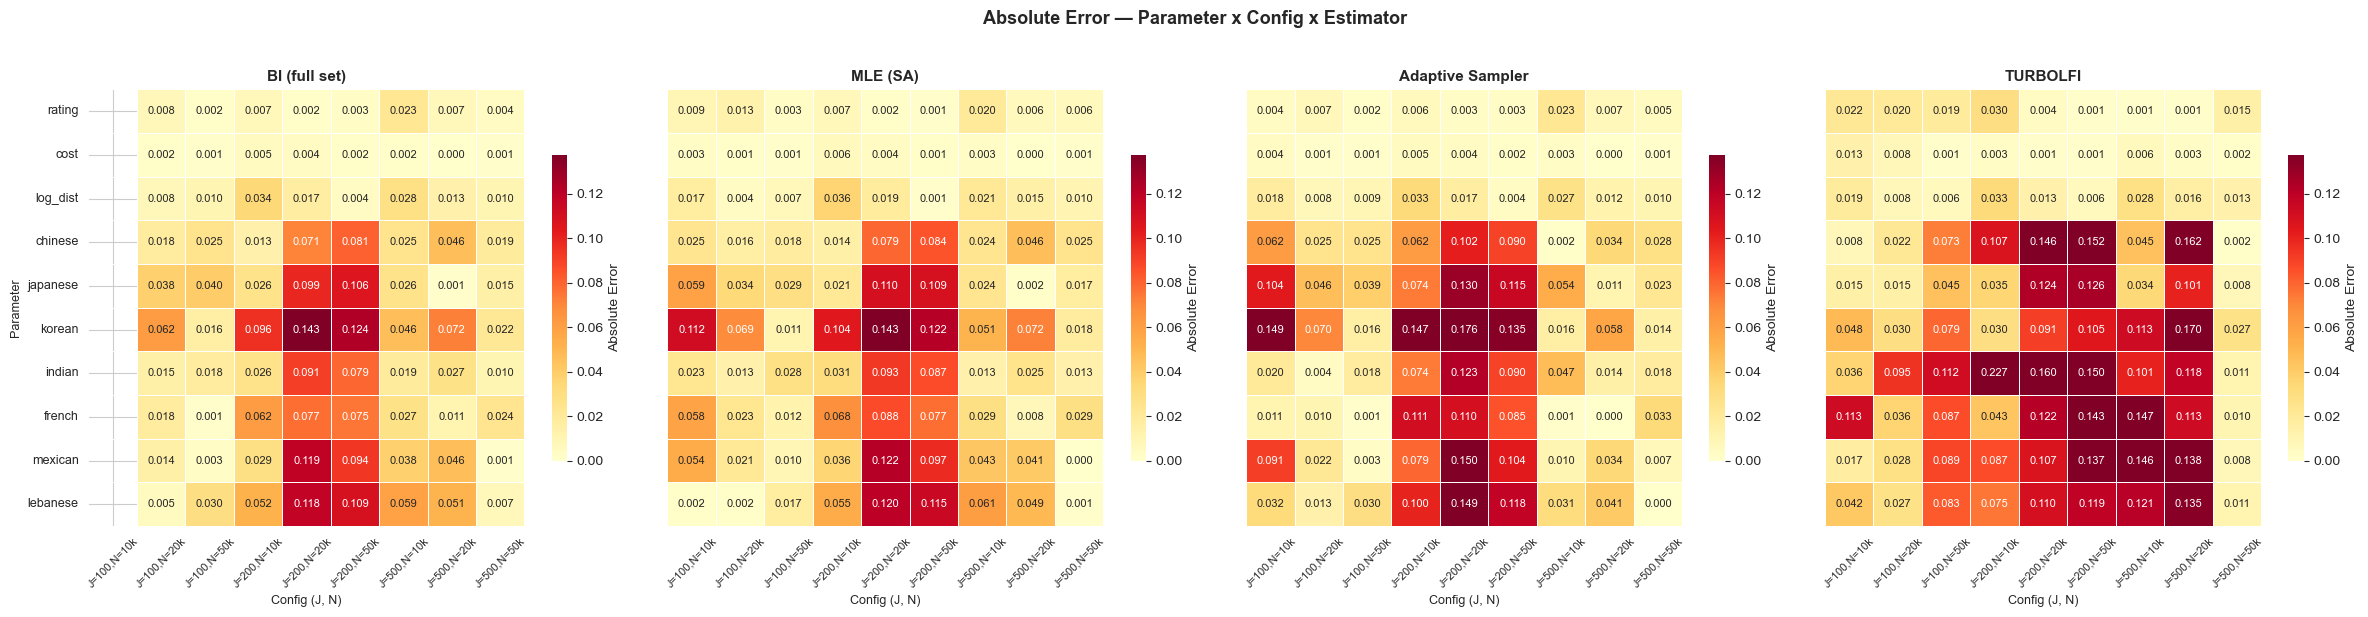

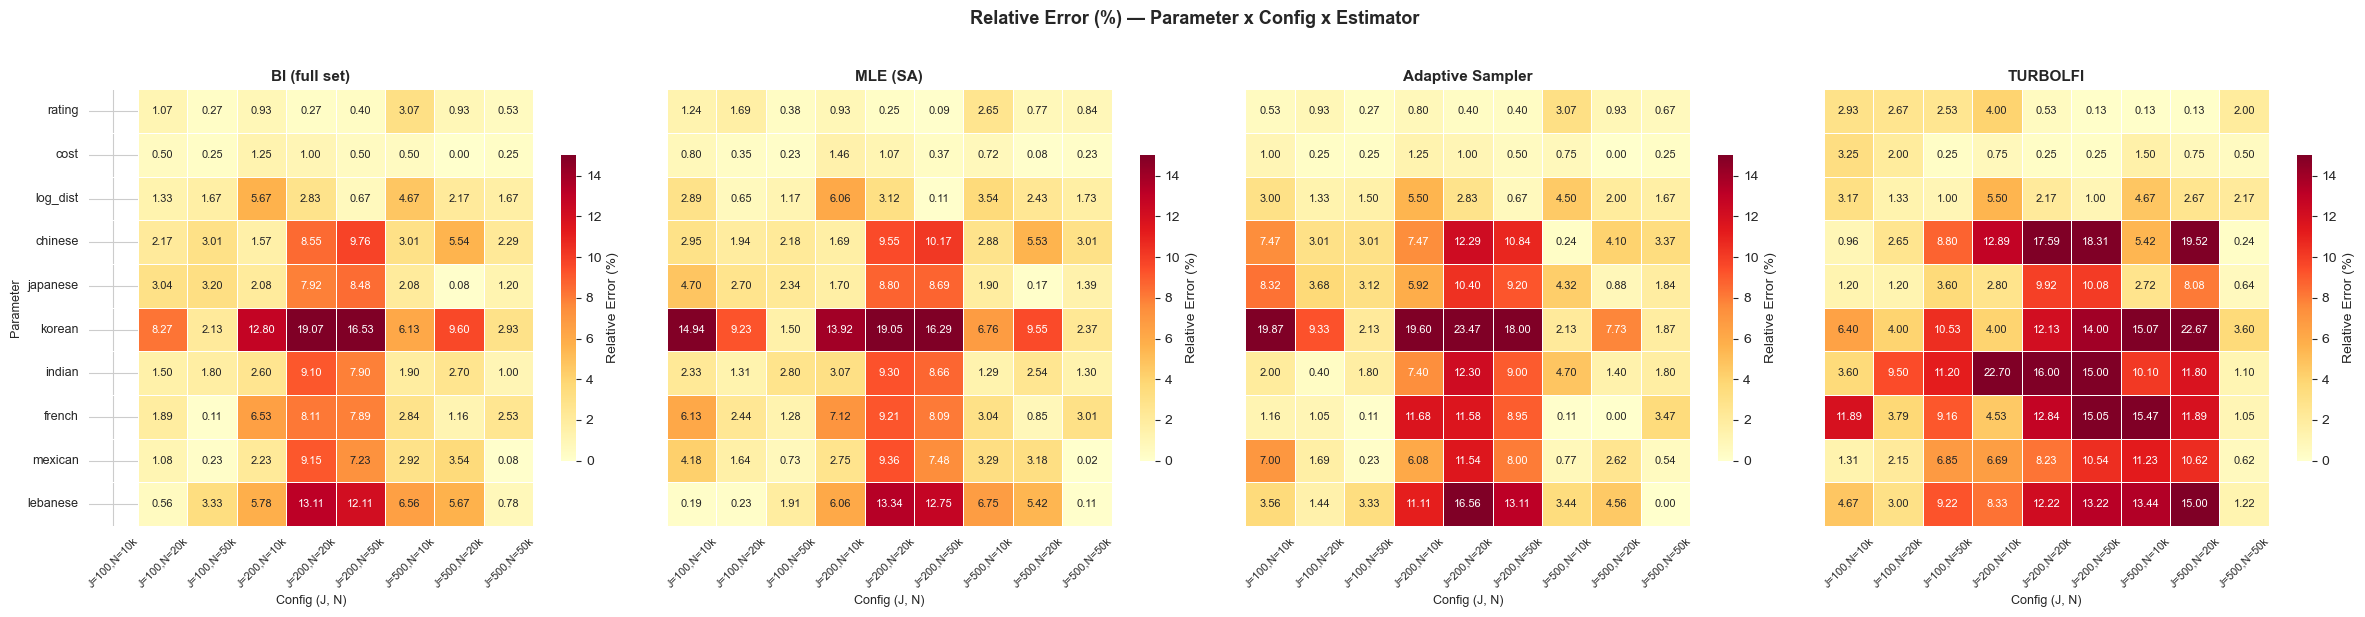

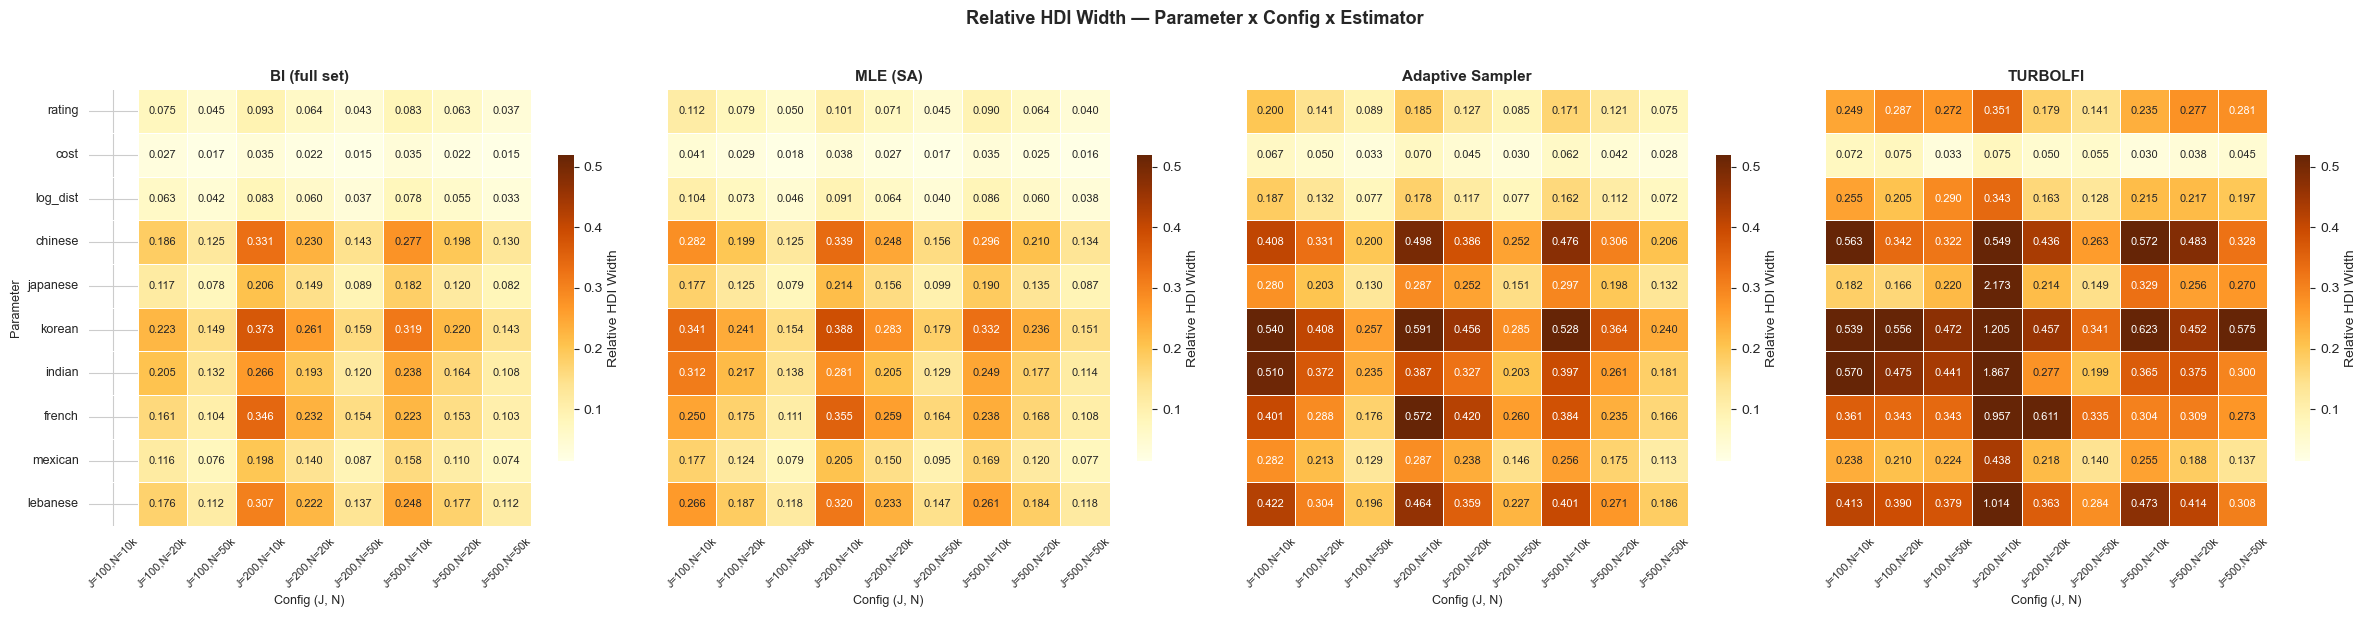

In [18]:
# ── Heatmaps: abs_error and rel_width — parameter × config, per estimator ─────
df_all_ext2 = df_all_ext.copy()
df_all_ext2['config'] = df_all_ext2.apply(lambda r: f"J={int(r['J'])},N={int(r['N'])//1000}k", axis=1)
config_order = sorted(df_all_ext2['config'].unique(),
                      key=lambda s: (int(re.search(r'J=(\d+)', s).group(1)),
                                     int(re.search(r'N=(\d+)', s).group(1))))
param_short = [p.replace('beta_', '') for p in PARAM_NAMES_P10]

for metric, title, cmap in [
    ('abs_error',          'Absolute Error',       'YlOrRd'),
    ('abs_rel_error_pct',  'Relative Error (%)',   'YlOrRd'),
    ('relative_width',     'Relative HDI Width',   'YlOrBr'),
]:
    ests_avail = [e for e in ['BI', 'MLE', 'AdaptiveSampler', 'TURBOLFI'] if e in df_all_ext2['estimator'].unique()]
    n_e = len(ests_avail)
    fig, axes = plt.subplots(1, n_e, figsize=(6 * n_e, max(3, len(PARAM_NAMES_P10) * 0.45 + 1.5)),
                             sharey=True)
    if n_e == 1:
        axes = [axes]

    # Compute global vmin/vmax for consistent color scale
    vmin = df_all_ext2[df_all_ext2['parameter'].isin(PARAM_NAMES_P10)][metric].min()
    vmax = df_all_ext2[df_all_ext2['parameter'].isin(PARAM_NAMES_P10)][metric].quantile(0.95)

    for ax, est in zip(axes, ests_avail):
        ed = df_all_ext2[df_all_ext2['estimator'] == est]
        piv = (ed[ed['parameter'].isin(PARAM_NAMES_P10)]
               .pivot_table(index='parameter', columns='config', values=metric, aggfunc='mean')
               .reindex(index=PARAM_NAMES_P10, columns=config_order))
        piv.index = param_short

        fmt = '.2f' if metric == 'abs_rel_error_pct' else '.3f'
        sns.heatmap(piv, ax=ax, cmap=cmap, fmt=fmt, annot=True, annot_kws={'size': 8},
                    vmin=vmin, vmax=vmax, linewidths=0.4,
                    cbar_kws={'label': title, 'shrink': 0.7})
        ax.set_title(f'{ESTIMATOR_LABELS.get(est, est)}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Config (J, N)', fontsize=9)
        ax.set_ylabel('Parameter' if ax == axes[0] else '', fontsize=9)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.tick_params(axis='y', labelsize=9)

    fig.suptitle(f'{title} — Parameter x Config x Estimator',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 9. Convergence Diagnostics Comparison

Compare R-hat and ESS across estimators and configs. Reference lines:
- R-hat < 1.01 → excellent; < 1.05 → acceptable
- ESS > 400 → sufficient

In [19]:
conv = df_all.groupby(['estimator', 'J', 'N']).agg(
    max_rhat      = ('r_hat',     'max'),
    mean_rhat     = ('r_hat',     'mean'),
    min_ess_bulk  = ('ess_bulk',  'min'),
    mean_ess_bulk = ('ess_bulk',  'mean'),
    min_ess_tail  = ('ess_tail',  'min'),
).reset_index()

conv['converged'] = (conv['max_rhat'] < 1.05) & (conv['min_ess_bulk'] > 400) & (conv['min_ess_tail'] > 400)

print("=" * 75)
print("CONVERGENCE DIAGNOSTICS")
print("=" * 75)
display(
    conv.sort_values(['J', 'N', 'estimator'])
        [['estimator', 'J', 'N', 'max_rhat', 'mean_rhat',
          'min_ess_bulk', 'mean_ess_bulk', 'min_ess_tail', 'converged']]
        .round({'max_rhat': 4, 'mean_rhat': 4,
                'min_ess_bulk': 0, 'mean_ess_bulk': 0, 'min_ess_tail': 0})
)



n_converged = conv['converged'].sum()
n_total = len(conv)
print(f"\nConverged: {n_converged}/{n_total} ({n_converged/n_total*100:.0f}%)")
not_converged = conv[~conv['converged']][['estimator', 'J', 'N', 'max_rhat', 'min_ess_bulk']]
if not not_converged.empty:
    print("\nConfigs not converged:")
    display(not_converged)

CONVERGENCE DIAGNOSTICS


,estimator,J,N,max_rhat,mean_rhat,min_ess_bulk,mean_ess_bulk,min_ess_tail,converged
0,AdaptiveSampler,100,10000,1.04,1.020,104.0,502.0,234.0,False
17,MLE,100,10000,NaN,NaN,NaN,NaN,NaN,False
26,TURBOLFI,100,10000,1.01,1.008,521.0,611.0,926.0,True
1,AdaptiveSampler,100,20000,1.06,1.031,71.0,449.0,134.0,False
9,BI,100,20000,1.01,1.006,812.0,1456.0,1045.0,True
18,MLE,100,20000,NaN,NaN,NaN,NaN,NaN,False
27,TURBOLFI,100,20000,1.02,1.013,354.0,536.0,600.0,False
2,AdaptiveSampler,100,50000,1.04,1.021,70.0,443.0,136.0,False
10,BI,100,50000,1.02,1.009,290.0,684.0,544.0,False
19,MLE,100,50000,NaN,NaN,NaN,NaN,NaN,False



Converged: 10/35 (29%)

Configs not converged:


,estimator,J,N,max_rhat,min_ess_bulk
0,AdaptiveSampler,100,10000,1.04,104.0
1,AdaptiveSampler,100,20000,1.06,71.0
2,AdaptiveSampler,100,50000,1.04,70.0
3,AdaptiveSampler,200,10000,1.03,98.0
4,AdaptiveSampler,200,20000,1.08,43.0
5,AdaptiveSampler,200,50000,1.10,33.0
6,AdaptiveSampler,500,10000,1.04,87.0
7,AdaptiveSampler,500,20000,1.03,102.0
8,AdaptiveSampler,500,50000,1.06,98.0
10,BI,100,50000,1.02,290.0
